# Group G

- Shaheryar Waris  
- Maximilien
- Saad
- Talha

Envronment Used is esm-ws-24-25
Sources Used: 
- Chatgpt for code modification
- Workshop Material
- ERA-5 Dataset
- Provided Datasets

The following files should be in the directory to run this code.
- era5-2021-DE.nc
- GEBCO_2014_2D-DE.nc
- n_no_constraint_gurobi.nc
- no_CO2_model_gurobi.nc
- sensitivity_0_hydrogen.nc
- sensitivity_25_hydrogen.nc
- sensitivity_50_hydrogen.nc
- sensitivity_75_hydrogen.nc

Imports

In [4]:
from atlite.gis import ExclusionContainer
from atlite.gis import shape_availability
import atlite
from rasterio.plot import show
import geopandas as gpd
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import country_converter as coco
import atlite
import numpy as np
from urllib.request import urlretrieve

c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: File /vsimem/pyogrio_2e9b083858834bb68756f87406e9a8fc has GPKG application_id, but non conformant file extension
  return ogr_read(


   GID_0     GID_1  COUNTRY                  NAME_1  \
0    DEU   DEU.1_1  Germany       Baden-Württemberg   
1    DEU   DEU.2_1  Germany                  Bayern   
2    DEU   DEU.3_1  Germany                  Berlin   
3    DEU   DEU.4_1  Germany             Brandenburg   
4    DEU   DEU.5_1  Germany                  Bremen   
5    DEU   DEU.6_1  Germany                 Hamburg   
6    DEU   DEU.7_1  Germany                  Hessen   
7    DEU   DEU.8_1  Germany  Mecklenburg-Vorpommern   
8    DEU   DEU.9_1  Germany           Niedersachsen   
9    DEU  DEU.10_1  Germany     Nordrhein-Westfalen   
10   DEU  DEU.11_1  Germany         Rheinland-Pfalz   
11   DEU  DEU.12_1  Germany                Saarland   
12   DEU  DEU.14_1  Germany                 Sachsen   
13   DEU  DEU.13_1  Germany          Sachsen-Anhalt   
14   DEU  DEU.15_1  Germany      Schleswig-Holstein   
15   DEU  DEU.16_1  Germany               Thüringen   

                                             geometry  
0   MULT

<Axes: >

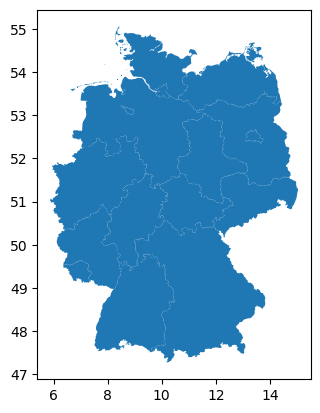

In [5]:
fn = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fgadm&files=gadm_410-levels-ADM_1-DEU.gpkg"
regions = gpd.read_file(fn)
print(regions)
regions.plot()

c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: File /vsimem/pyogrio_d687cfa12ad74880bc5863e042aedeab has GPKG application_id, but non conformant file extension
  return ogr_read(


,MRGID,GEONAME,MRGID_TER1,POL_TYPE,MRGID_SOV1,TERRITORY1,ISO_TER1,SOVEREIGN1,MRGID_TER2,MRGID_SOV2,...,ISO_SOV1,ISO_SOV2,ISO_SOV3,UN_SOV1,UN_SOV2,UN_SOV3,UN_TER1,UN_TER2,UN_TER3,geometry
217,5669.0,German Exclusive Economic Zone,2101.0,200NM,2101.0,Germany,DEU,Germany,0.0,0.0,...,DEU,None,None,276,NaN,NaN,276.0,NaN,NaN,"MULTIPOLYGON (((14.09923 53.86999, 14.11579 53..."


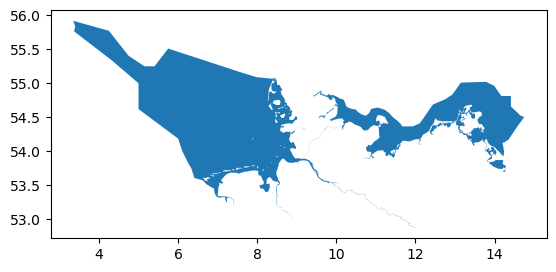

In [6]:
url = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fmarineregions%2FWorld_EEZ_v11_20191118_gpkg&files=eez_v11.gpkg"
# Load the GeoPackage
marine_regions = gpd.read_file(url)
# Check the data
germany_gdf = marine_regions[marine_regions['SOVEREIGN1'] == 'Germany']
germany_gdf.plot()
display(germany_gdf)

<Axes: >

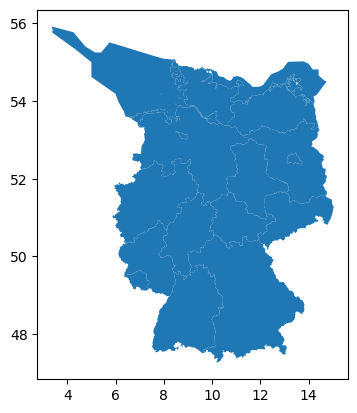

In [7]:
new_row_data = {
    "GID_0": "DEU",                     
    "GID_1": "DEU.17_1",               
    "COUNTRY": "Germany",                
    "NAME_1": germany_gdf["GEONAME"].iloc[0],                
}

new_row_geometry =  germany_gdf["geometry"].iloc[0]

new_row = gpd.GeoDataFrame([new_row_data], geometry=[new_row_geometry], crs=regions.crs)

germany_merged = pd.concat([regions, new_row], ignore_index=True)

germany_merged.plot()

In [8]:
from matplotlib import colors
import matplotlib.colors as mcolors

# Step 1: Initialize a 'group' column with None or empty values
germany_merged['group'] = None

# Step 2: Manually assign each region (GID_1) to one of the 6 groups
groups = {
    1: ["DEU.9_1", "DEU.5_1", "DEU.6_1", "DEU.15_1"],  # Group 1 regions
    2: ["DEU.8_1", "DEU.3_1", "DEU.4_1"],  # Group 2 regions
    3: ["DEU.13_1", "DEU.16_1", "DEU.14_1"],  # Group 3 regions
    4: ["DEU.10_1", "DEU.11_1", "DEU.12_1", "DEU.7_1"],  # Group 4 regions
    5: ["DEU.2_1", "DEU.1_1"],  # Group 5
    6: ["DEU.17_1"]  # Group 6 (Economic Zone / Sea Area)
}

# Step 3: Assign the 'group' number based on the GID_1 value
for group, gid_values in groups.items():
    for gid in gid_values:
        germany_merged.loc[germany_merged['GID_1'] == gid, 'group'] = group

#Merge the geometries based on the group
merged_geometries = germany_merged.groupby('group').geometry.apply(lambda x: x.unary_union)

# Step 5: Create a new GeoDataFrame with the merged geometries
# After groupby operation, we need to keep track of the 'group' column.
merged_gdf = gpd.GeoDataFrame(merged_geometries, columns=['geometry'], crs=germany_merged.crs)

# Add the 'group' column to merged_gdf for plotting purposes
merged_gdf['group'] = merged_geometries.index  # The index now represents the 'group' value
merged_gdf = merged_gdf.drop(columns=['group'])
print(merged_gdf)


C:\Users\Sherry\AppData\Local\Temp\ipykernel_1688\3338829589.py:23: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_geometries = germany_merged.groupby('group').geometry.apply(lambda x: x.unary_union)


                                                geometry
group                                                   
1      MULTIPOLYGON (((6.77028 53.61653, 6.77083 53.6...
2      MULTIPOLYGON (((12.28311 52.22825, 12.28353 52...
3      POLYGON ((11.25267 50.26939, 11.2523 50.26902,...
4      MULTIPOLYGON (((7.19668 49.12022, 7.19647 49.1...
5      MULTIPOLYGON (((8.67649 47.69794, 8.67512 47.7...
6      MULTIPOLYGON (((14.11579 53.86848, 14.12778 53...


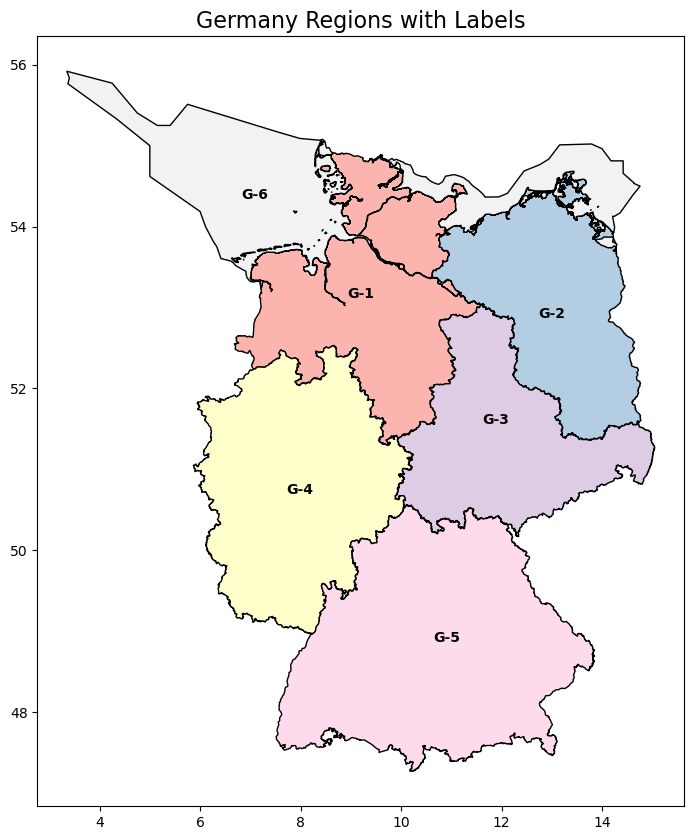

In [9]:

#Plot the merged regions with labels
fig, ax = plt.subplots(figsize=(10, 10))

# Use the newly created 'index' column for coloring
merged_gdf.plot(ax=ax, legend=False, edgecolor='black', cmap='Pastel1')

# Step 7: Add text labels to each group using representative_point
for idx, row in merged_gdf.iterrows():
    representative_point = row['geometry'].representative_point()
    region_label = f'G-{idx}'  # Numbering starts from 1
    ax.text(representative_point.x, representative_point.y, region_label,
            ha='center', va='center', fontsize=10, fontweight='bold', color='black')

# Step 4: Add title and show plot
plt.title("Germany Regions with Labels", fontsize=16)
plt.axis('on')  # Ensures axis is visible if needed
plt.show()


In [10]:
import rasterio
from rasterio.plot import show
from rasterio.crs import CRS

## Onwind Eligibility

In [13]:
# Step 1: Define the URLs for each dataset
natura2000_url = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fwdpa&files=WDPA_Oct2022_Public_shp-DEU.tif"
airports_url = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2F&files=ne_10m_airports.gpkg"
roads_url = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2F&files=ne_10m_roads.gpkg"
elevation_url = "GEBCO_2014_2D-DE.nc"

# Step 2: Load the Natura2000 dataset for natural protection areas
natura2000 = rasterio.open(natura2000_url)

# Step 3: Load the airports dataset (10 km buffer around airports)
airports = gpd.read_file(airports_url)

# Step 4: Load the roads dataset (300 m buffer around major roads)
roads = gpd.read_file(roads_url)

# Step 5: Load the URL for Land cover 100m resolution
land_url = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fcopernicus-glc&files=PROBAV_LC100_global_v3.0.1_2019-nrt_Discrete-Classification-map_EPSG-4326-DE.tif"
land = rasterio.open(land_url)

elevation = rasterio.open(elevation_url, driver ="netcdf")


c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: File /vsimem/pyogrio_f4c8ffe03bba4b1fa7a789cd7b2fa5e7 has GPKG application_id, but non conformant file extension
  return ogr_read(
c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: File /vsimem/pyogrio_a695f1a2f8434ed59b99f89f2a75e583 has GPKG application_id, but non conformant file extension
  return ogr_read(


In [14]:
from atlite.gis import ExclusionContainer

# Step 1: Initialize the exclusion container
excluder = ExclusionContainer(crs=3035, res=100)  # Set CRS and resolution

# Step 2: Add exclusion layers

# Protected areas (Natura2000)
excluder.add_raster(natura2000_url, crs=3035)

# Airports with 10 km buffer
excluder.add_geometry(airports_url, buffer=10000)

# Roads with 300 m buffer
excluder.add_geometry(roads_url, buffer=300)

# # Elevation above 2000 m
excluder.add_raster(elevation_url, codes=lambda x: x < 2000, crs=4326, invert=True)

# Built-up areas (Copernicus classification)
excluder.add_raster(land_url, codes=[50], buffer=1000, crs=3025)

# Step 3: Include suitable land cover classes for wind turbines

# Using Copernicus land cover codes: 30 (Herbaceous), 20 (Shrubs), 60 (Bare/Sparse), 125 (Open Forest, Mixed), 40 (Agriculture)
excluder.add_raster(
    land_url,
    codes=[30, 20, 60, 125, 40],
    crs=4326,
    invert=True  # Include only these classes
)

# Step 3: Verify the exclusion container
print(excluder)


Exclusion Container
 registered rasters: 4 
 registered geometry collections: 2
 CRS: 3035 - Resolution: 100


c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: File /vsimem/pyogrio_3dfc5fe8bba54ddd9a1c110fa467c8f8 has GPKG application_id, but non conformant file extension
  return ogr_read(
c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: File /vsimem/pyogrio_30ce1f2e60dd4dbfa0dc73047fc01ecb has GPKG application_id, but non conformant file extension
  return ogr_read(


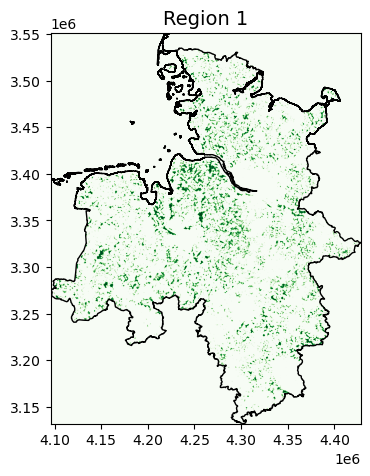

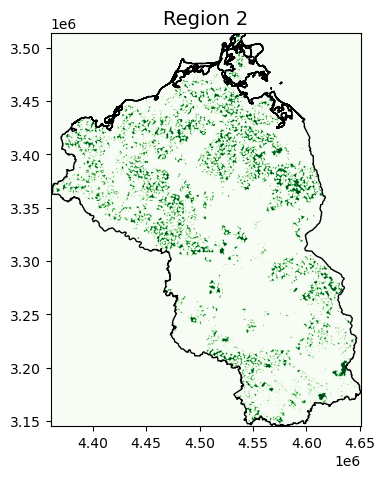

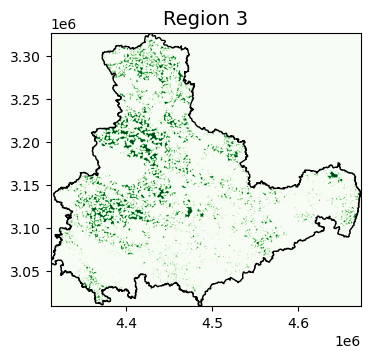

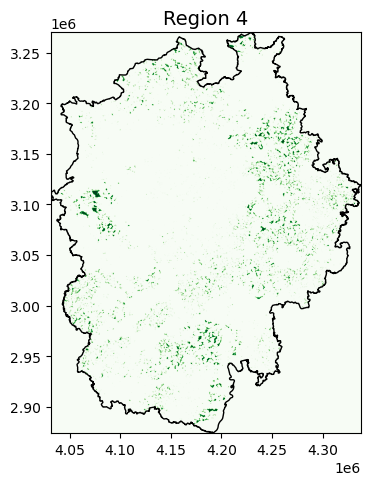

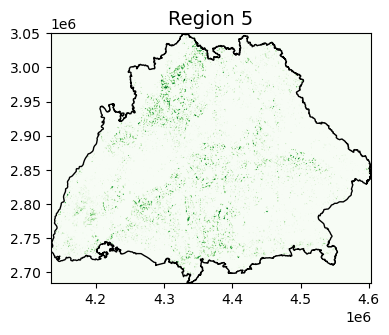

In [15]:
area_results = []

for i in range(1,6):
    fig, ax = plt.subplots(figsize=(4, 8))
    # Extract region geometry
    region = merged_gdf.loc[[i]].to_crs(excluder.crs).geometry
    # Call shape_availability to get band and transform (assuming excluder is already defined)
    band, transform = shape_availability(region, excluder)
    # Plot the region in the current subplot (ax is the axis for each subplot)
    region.plot(ax=ax, color="none")
    
    # Overlay the band (if applicable)
    show(band, transform=transform, cmap="Greens", ax=ax)
    ax.set_title(f"Region {i}", fontsize=14)

    eligible_cells = np.sum(band)
    cell_area = np.float64(excluder.res**2)
    eligible_area = np.float64(cell_area * eligible_cells)
    region_area = region.geometry.area.iloc[0]
    percent_area = round(eligible_area / region_area * 100,2)
    area_results.append({
        'Region_ID': i,
        'Eligible_Area': eligible_area,
        'Region_Area': region_area,
        'Percentage_Area': percent_area
    })

area_df = pd.DataFrame(area_results)
# Adjust layout to avoid overlapping
plt.tight_layout()

# Show the plot
plt.show()

In [16]:
onwind_area = area_df

onwind_area["p_nom_max"] = onwind_area["Eligible_Area"]*(3/1e6)
onwind_area.set_index("Region_ID", inplace=True)
display(onwind_area)

,Eligible_Area,Region_Area,Percentage_Area,p_nom_max
Region_ID,,,,
1,5.741680e+09,6.443712e+10,8.91,17225.04
2,5.477780e+09,5.392263e+10,10.16,16433.34
3,5.152850e+09,5.520224e+10,9.33,15458.55
4,2.530520e+09,7.765821e+10,3.26,7591.56
5,3.460390e+09,1.066037e+11,3.25,10381.17


## Offshore wind Eligibility

c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: File /vsimem/pyogrio_ca626d587d7147cd8465f5f19fff4479 has GPKG application_id, but non conformant file extension
  return ogr_read(


EPSG:3035


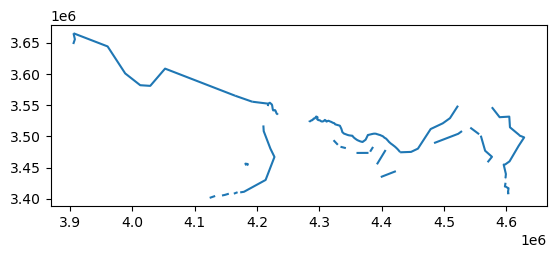

In [17]:
url = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fmarineregions%2FWorld_EEZ_v11_20191118_gpkg&files=eez_boundaries_v11.gpkg"


eez_boundaries = gpd.read_file(url)

# Check the data
germany_shoreline = eez_boundaries[eez_boundaries['SOVEREIGN1'] == 'Germany']
germany_shoreline = germany_shoreline.to_crs(epsg=3035)

germany_shoreline.plot()
print(germany_shoreline.crs)

In [18]:

# Step 1: Initialize the exclusion container
excluder_offshore = ExclusionContainer(crs=3035, res=100)  # Set CRS and resolution

# # Protected areas (Natura2000)
excluder_offshore.add_raster(natura2000_url, crs=3035)

# Elevation till depth of 50m
excluder_offshore.add_raster(elevation_url, codes=lambda x: (x <= 0) & (x >= -50), crs=4326, invert=True)

# Adding 10km for shoreline
excluder_offshore.add_geometry(germany_shoreline, buffer=10_000)

# Step 3: Verify the exclusion container
print(excluder_offshore)


Exclusion Container
 registered rasters: 2 
 registered geometry collections: 1
 CRS: 3035 - Resolution: 100


Text(0.5, 1.0, 'Area for Offshore Wind')

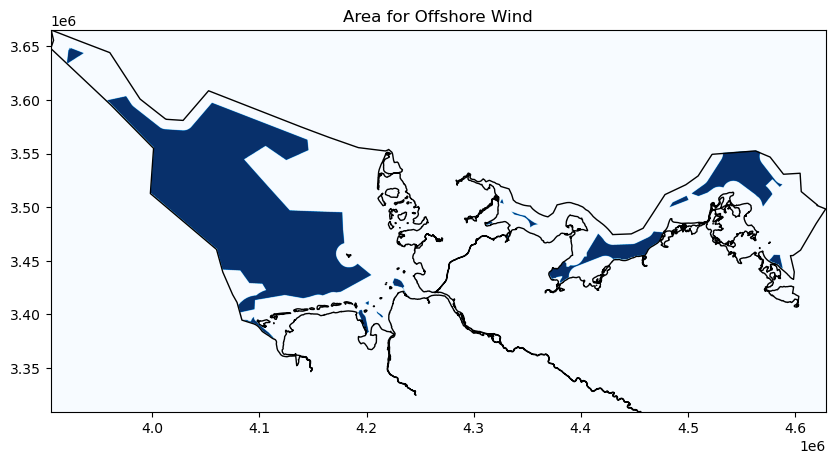

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
    # Extract region geometry
region = merged_gdf.loc[[6]].to_crs(excluder_offshore.crs).geometry
    # Call shape_availability to get band and transform (assuming excluder is already defined)
band, transform = shape_availability(region, excluder_offshore)
    # Plot the region in the current subplot (ax is the axis for each subplot)
region.plot(ax=ax, color="none")
    # Overlay the band (if applicable)
show(band, transform=transform, cmap="Blues", ax=ax) 
plt.title("Area for Offshore Wind")

In [20]:
eligible_cells = np.sum(band)
cell_area = np.float64(excluder_offshore.res**2)
eligible_area = np.float64(cell_area * eligible_cells)
region_area = region.geometry.area.iloc[0]
percent_area = eligible_area / region_area * 100
print(f"eligible cells = {eligible_cells}")
print(f"region_area = {region_area}")
print(f"eligible Area = {eligible_area}")
print(f"Area available  = {percent_area:.2f}")

p_nom_max_offwind = eligible_area*(3/1e6)
print(p_nom_max_offwind)

eligible cells = 2362612
region_area = 56762069469.05456
eligible Area = 23626120000.0
Area available  = 41.62
70878.36


### Solar Eligibility

In [21]:
# Step 1: Initialize the exclusion container
excluder_solar = ExclusionContainer(crs=3035, res=100)  # Set CRS and resolution

# Step 2: Add exclusion layers

# Protected areas (Natura2000)
excluder_solar.add_raster(natura2000_url, crs=3035)

excluder_solar.add_raster(
    land_url,
    codes=[60, 50, 40],
    crs=4326,
    invert=True  # Include only these classes
)

# Step 3: Verify the exclusion container
print(excluder_solar)


Exclusion Container
 registered rasters: 2 
 registered geometry collections: 0
 CRS: 3035 - Resolution: 100


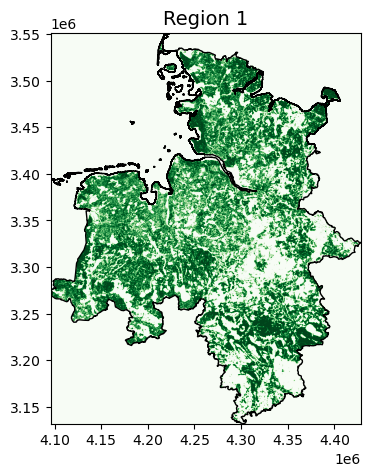

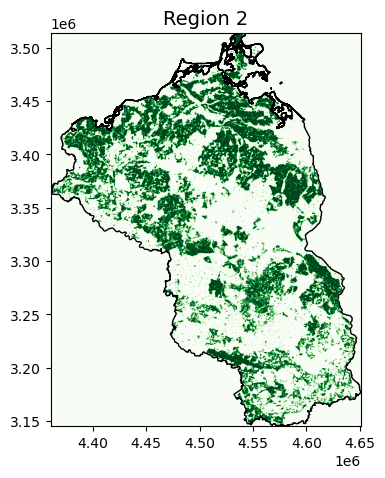

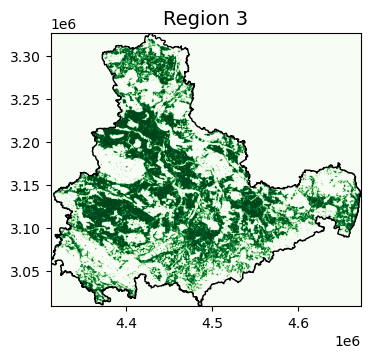

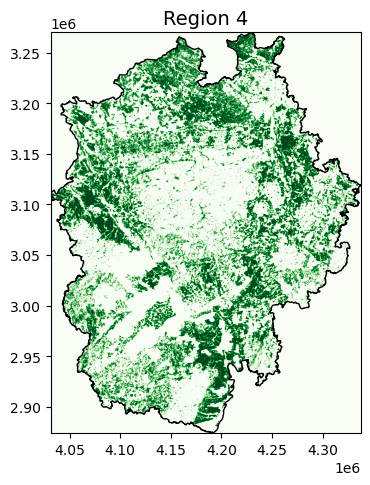

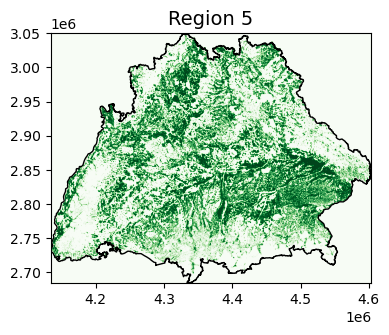

In [22]:
area_results = []
for i in range(1,6):
    fig, ax = plt.subplots(figsize=(4, 8))
    # Extract region geometry
    region = merged_gdf.loc[[i]].to_crs(excluder_solar.crs).geometry
    # Call shape_availability to get band and transform (assuming excluder is already defined)
    band, transform = shape_availability(region, excluder_solar)
    # Plot the region in the current subplot (ax is the axis for each subplot)
    region.plot(ax=ax, color="none")
    ax.set_title(f"Region {i}", fontsize=14)
    # Overlay the band (if applicable)
    show(band, transform=transform, cmap="Greens", ax=ax)

    eligible_cells = np.sum(band)
    cell_area = np.float64(excluder.res**2)
    eligible_area = np.float64(cell_area * eligible_cells)
    region_area = region.geometry.area.iloc[0]
    percent_area = round(eligible_area / region_area * 100,2)
    area_results.append({
        'Region_ID': i,
        'Eligible_Area': eligible_area,
        'Region_Area': region_area,
        'Percentage_Area': percent_area
    })

area_solar_df = pd.DataFrame(area_results)
# Adjust layout to avoid overlapping
plt.tight_layout()

# Show the plot
plt.show()

In [23]:
solar_area = area_solar_df
solar_area["p_nom_max"] = solar_area["Eligible_Area"]*(3/1e6)  ### 3 MW/km2 to 3MW/m2
solar_area.set_index("Region_ID", inplace=True)
display(solar_area)

,Eligible_Area,Region_Area,Percentage_Area,p_nom_max
Region_ID,,,,
1,3.326580e+10,6.443712e+10,51.63,99797.40
2,1.988376e+10,5.392263e+10,36.87,59651.28
3,2.556261e+10,5.520224e+10,46.31,76687.83
4,2.667881e+10,7.765821e+10,34.35,80036.43
5,4.034954e+10,1.066037e+11,37.85,121048.62


### ERA-5 Cutout Loadout

In [24]:
from atlite.gis import ExclusionContainer
from atlite.gis import shape_availability
import atlite
from rasterio.plot import show
import xarray as xr
import country_converter as coco
import atlite

<Axes: >

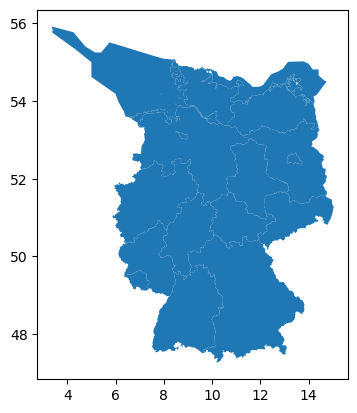

In [25]:
germany_merged.plot()

In [26]:
minx, miny, maxx, maxy = germany_merged.total_bounds
buffer = 0.25

print(minx)
print(maxx)
print(miny)
print(maxy)

3.349999999800559
15.041814803000136
47.27069713400016
55.9192777774912


In [27]:
cutout = atlite.Cutout(
path="era5-2021-DE.nc",
module="era5",
x=slice(minx - buffer, maxx + buffer),
y=slice(miny - buffer, maxy + buffer),
time=slice("2021-01-01", "2021-12-31"),
)

c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\atlite\cutout.py:191: UserWarning: Arguments module, x, y, time are ignored, since cutout is already built.
  warn(


In [56]:
## cutout.prepare(monthly_requests=True, compression=None)

2025-02-02 18:17:25,730 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-02-02 18:17:25,740 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-02-02 18:17:30,500 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-02-02 18:36:14,121 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or par

<Cutout "era5-2021-DE">
 x = 3.25 ⟷ 15.25, dx = 0.25
 y = 47.25 ⟷ 56.00, dy = 0.25
 time = 2021-01-01 ⟷ 2021-12-31, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

In [28]:
cutout.data

<xarray.Dataset> Size: 927MB
Dimensions:               (x: 49, y: 36, time: 8760)
Coordinates:
  * x                     (x) float64 392B 3.25 3.5 3.75 ... 14.75 15.0 15.25
  * y                     (y) float64 288B 47.25 47.5 47.75 ... 55.5 55.75 56.0
  * time                  (time) datetime64[ns] 70kB 2021-01-01 ... 2021-12-3...
    lon                   (x) float64 392B dask.array<chunksize=(49,), meta=np.ndarray>
    lat                   (y) float64 288B dask.array<chunksize=(36,), meta=np.ndarray>
Data variables: (12/14)
    height                (y, x) float32 7kB dask.array<chunksize=(36, 49), meta=np.ndarray>
    wnd100m               (time, y, x) float32 62MB dask.array<chunksize=(100, 36, 49), meta=np.ndarray>
    wnd_azimuth           (time, y, x) float32 62MB dask.array<chunksize=(100, 36, 49), meta=np.ndarray>
    roughness             (time, y, x) float32 62MB dask.array<chunksize=(100, 36, 49), meta=np.ndarray>
    influx_toa            (time, y, x) float32 62MB dask.array<chunksize=(100, 36, 49), meta=np.ndarray>
    influx_direct         (time, y, x) float32 62MB dask.array<chunksize=(100, 36, 49), meta=np.ndarray>
    ...                    ...
    solar_altitude        (time, y, x) float64 124MB dask.array<chunksize=(100, 36, 49), meta=np.ndarray>
    solar_azimuth         (time, y, x) float64 124MB dask.array<chunksize=(100, 36, 49), meta=np.ndarray>
    temperature           (time, y, x) float32 62MB dask.array<chunksize=(100, 36, 49), meta=np.ndarray>
    soil temperature      (time, y, x) float32 62MB dask.array<chunksize=(100, 36, 49), meta=np.ndarray>
    dewpoint temperature  (time, y, x) float32 62MB dask.array<chunksize=(100, 36, 49), meta=np.ndarray>
    runoff                (time, y, x) float32 62MB dask.array<chunksize=(100, 36, 49), meta=np.ndarray>
Attributes:
    module:                  era5
    prepared_features:       ['runoff', 'temperature', 'height', 'influx', 'w...
    chunksize_time:          100
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-02-02T17:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [29]:
merged_gdf_onshore = merged_gdf.drop(6)
merged_gdf_offshore = merged_gdf.loc[6:6]
display(merged_gdf_onshore)
display(merged_gdf_offshore)


,geometry
group,
1,"MULTIPOLYGON (((6.77028 53.61653, 6.77083 53.6..."
2,"MULTIPOLYGON (((12.28311 52.22825, 12.28353 52..."
3,"POLYGON ((11.25267 50.26939, 11.2523 50.26902,..."
4,"MULTIPOLYGON (((7.19668 49.12022, 7.19647 49.1..."
5,"MULTIPOLYGON (((8.67649 47.69794, 8.67512 47.7..."


,geometry
group,
6,"MULTIPOLYGON (((14.11579 53.86848, 14.12778 53..."


# Solar Time Series

In [30]:
A_solar = cutout.availabilitymatrix(merged_gdf_onshore, excluder_solar)

In [31]:
cap_per_sqkm = 3  # MW/km2
area = cutout.grid.set_index(["y", "x"]).to_crs(3035).area / 1e6
area = xr.DataArray(area, dims=("spatial"))
capacity_matrix = A_solar.stack(spatial=["y", "x"]) * area * cap_per_sqkm

In [32]:
pv = cutout.pv(
    panel=atlite.solarpanels.CdTe,
    matrix=capacity_matrix,
    orientation="latitude_optimal",
    index=merged_gdf_onshore.index,
    per_unit=True,
)

In [33]:
pv = pv.to_pandas()
time_series_solar = pv.resample('3h').mean()

group,1,2,3,4,5
time,,,,,
2021-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
2021-01-01 03:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
2021-01-01 06:00:00,0.000000,0.001513,0.003472,0.000000,0.013001
2021-01-01 09:00:00,0.126574,0.093789,0.146353,0.118016,0.199459
2021-01-01 12:00:00,0.173518,0.099134,0.164416,0.189242,0.277120
...,...,...,...,...,...
2021-12-31 09:00:00,0.055421,0.029805,0.174622,0.134538,0.331497
2021-12-31 12:00:00,0.047566,0.034614,0.154286,0.176304,0.412198
2021-12-31 15:00:00,0.002206,0.001809,0.007108,0.043280,0.050856


<Axes: xlabel='time'>

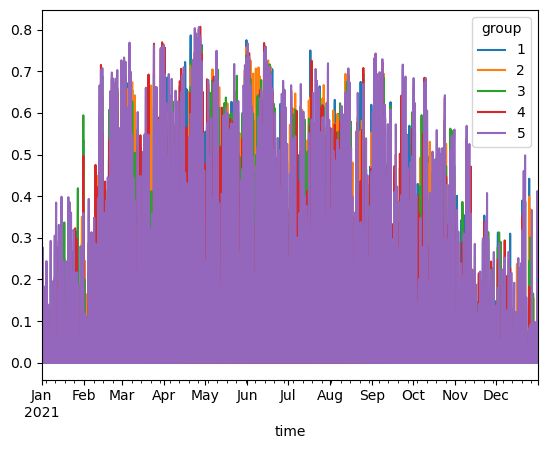

In [34]:
display(time_series_solar)
time_series_solar.plot()

# OnShore Wind Time Series

In [35]:
A_onshore_wind = cutout.availabilitymatrix(merged_gdf_onshore, excluder)

cap_per_sqkm = 3  # MW/km2 #Use 3 here
area = cutout.grid.set_index(["y", "x"]).to_crs(3035).area / 1e6
area = xr.DataArray(area, dims=("spatial"))
capacity_matrix = A_onshore_wind.stack(spatial=["y", "x"]) * area * cap_per_sqkm


onshorewind = cutout.wind(
    atlite.windturbines.Vestas_V112_3MW,
    matrix=capacity_matrix,
    index=merged_gdf_onshore.index,
    per_unit=True,
)

onshorewind = onshorewind.to_pandas()
time_series_onshore_wind = onshorewind.resample('3h').mean()

c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\atlite\resource.py:72: FutureWarning: 'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.
  warnings.warn(msg, FutureWarning)


group,1,2,3,4,5
time,,,,,
2021-01-01 00:00:00,0.082417,0.100420,0.051114,0.019120,0.047552
2021-01-01 03:00:00,0.063166,0.076524,0.029142,0.023393,0.024562
2021-01-01 06:00:00,0.052853,0.065231,0.027198,0.021721,0.012570
2021-01-01 09:00:00,0.053832,0.036936,0.022953,0.015142,0.003918
2021-01-01 12:00:00,0.055149,0.053353,0.017930,0.019175,0.000215
...,...,...,...,...,...
2021-12-31 09:00:00,0.970781,0.939234,0.751334,0.520797,0.109961
2021-12-31 12:00:00,0.927368,0.958169,0.777222,0.522968,0.122900
2021-12-31 15:00:00,0.929377,0.922061,0.788455,0.568740,0.352857


<Axes: xlabel='time'>

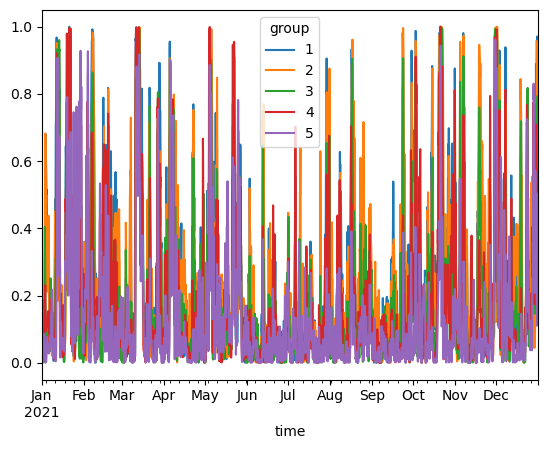

In [36]:
display(time_series_onshore_wind)
time_series_onshore_wind.plot()

# Offshore Wind TimeSeries

In [37]:
A_offshore_wind = cutout.availabilitymatrix(merged_gdf_offshore, excluder_offshore)

cap_per_sqkm = 3  # MW/km2 #Use 3 here
area = cutout.grid.set_index(["y", "x"]).to_crs(3035).area / 1e6
area = xr.DataArray(area, dims=("spatial"))
capacity_matrix = A_offshore_wind.stack(spatial=["y", "x"]) * area * cap_per_sqkm


offshorewind = cutout.wind(
    atlite.windturbines.NREL_ReferenceTurbine_5MW_offshore,
    matrix=capacity_matrix,
    index=merged_gdf_offshore.index,
    per_unit=True,
)

offshorewind = offshorewind.to_pandas()
time_series_offshore_wind = offshorewind.resample('3h').mean()

c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\atlite\resource.py:72: FutureWarning: 'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.
  warnings.warn(msg, FutureWarning)


group,6
time,
2021-01-01 00:00:00,0.084732
2021-01-01 03:00:00,0.081284
2021-01-01 06:00:00,0.062826
2021-01-01 09:00:00,0.101970
2021-01-01 12:00:00,0.139222
...,...
2021-12-31 09:00:00,0.997134
2021-12-31 12:00:00,0.995743
2021-12-31 15:00:00,0.998660


<Axes: xlabel='time'>

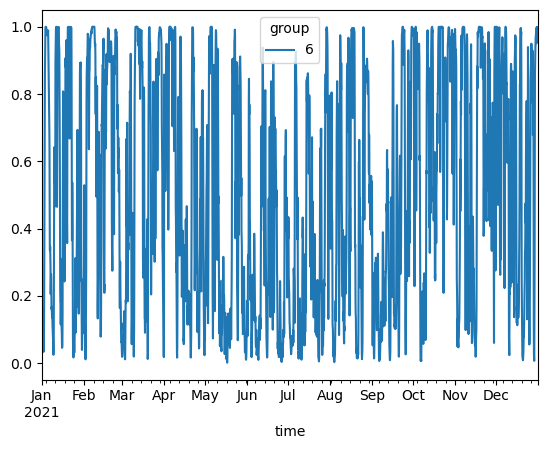

In [38]:
display(time_series_offshore_wind)
time_series_offshore_wind.plot()

## Existing Power Plants

One Generator Per Technology and Region

In [39]:
df = pd.read_csv("https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fglobal-power-plant-database&files=global_power_plant_database.csv", low_memory =False)
plants_DE = df[df["country"]=="DEU"]
primary_fuels = plants_DE.groupby("primary_fuel")["capacity_mw"].sum()

print(primary_fuels)

primary_fuel
Biomass     1655.30000
Coal       47772.90000
Gas        24430.25000
Hydro       9984.10000
Nuclear    11171.00000
Oil         2851.20000
Other        756.90000
Solar       6770.56288
Waste       1588.80000
Wind        5059.36200
Name: capacity_mw, dtype: float64


In [40]:
#  Disregard existing wind and solar and other capacities
plants_DE = plants_DE.drop(plants_DE[(plants_DE.primary_fuel == "Solar")].index)
plants_DE = plants_DE.drop(plants_DE[(plants_DE.primary_fuel == "Wind")].index)
plants_DE = plants_DE.drop(plants_DE[(plants_DE.primary_fuel == "Other")].index)


In [41]:
# Creating a Goedataframes 
plants_DE_gdf =gpd.GeoDataFrame(plants_DE, geometry=gpd.points_from_xy(plants_DE.longitude, plants_DE.latitude))

#COnverting to CRS 4326

plants_DE_gdf.set_crs(epsg=4326, inplace=True)

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017,geometry
12478,DEU,Germany,ADS-Anlage,WRI1005572,96.5,50.0918,8.5311,Gas,NaN,NaN,...,NaN,NaN,NaN,373.97,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (8.5311 50.0918)
12479,DEU,Germany,AHKW Neunkirchen,WRI1005573,11.6,49.3386,7.1700,Waste,NaN,NaN,...,NaN,NaN,NaN,24.40,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (7.17 49.3386)
12480,DEU,Germany,AMK - Abfallentsorgungsgesellschaft des Märkis...,WRI1005577,12.6,51.3971,7.6967,Waste,NaN,NaN,...,NaN,NaN,NaN,26.51,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (7.6967 51.3971)
12481,DEU,Germany,AVA GmbH,WRI1005580,10.0,48.4011,10.9356,Waste,NaN,NaN,...,NaN,NaN,NaN,21.04,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (10.9356 48.4011)
12482,DEU,Germany,AVA Velsen,WRI1005581,15.8,49.2139,6.8345,Waste,NaN,NaN,...,NaN,NaN,NaN,33.24,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (6.8345 49.2139)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13764,DEU,Germany,ZWSF,WRI1006155,2.5,52.5350,12.3626,Waste,NaN,NaN,...,NaN,NaN,NaN,5.26,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (12.3626 52.535)
13773,DEU,Germany,Zellstoff Stendal GmbH,WRI1006151,138.9,52.7271,12.0112,Biomass,NaN,NaN,...,NaN,NaN,NaN,NaN,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,POINT (12.0112 52.7271)
13774,DEU,Germany,Zeltingen,WRI1006152,13.6,49.9511,7.0232,Hydro,NaN,NaN,...,59.83,65.31,58.91,53.74,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,POINT (7.0232 49.9511)
13781,DEU,Germany,Zielitz,WRI1006153,52.0,52.2985,11.6796,Gas,NaN,NaN,...,NaN,NaN,NaN,201.52,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (11.6796 52.2985)


In [42]:
# Assigning Plants to each region.
plants_DE_regions = gpd.sjoin(plants_DE_gdf, merged_gdf, how="left", predicate="within")

display(plants_DE_regions)

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017,geometry,group
12478,DEU,Germany,ADS-Anlage,WRI1005572,96.5,50.0918,8.5311,Gas,NaN,NaN,...,NaN,NaN,373.97,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (8.5311 50.0918),4.0
12479,DEU,Germany,AHKW Neunkirchen,WRI1005573,11.6,49.3386,7.1700,Waste,NaN,NaN,...,NaN,NaN,24.40,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (7.17 49.3386),4.0
12480,DEU,Germany,AMK - Abfallentsorgungsgesellschaft des Märkis...,WRI1005577,12.6,51.3971,7.6967,Waste,NaN,NaN,...,NaN,NaN,26.51,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (7.6967 51.3971),4.0
12481,DEU,Germany,AVA GmbH,WRI1005580,10.0,48.4011,10.9356,Waste,NaN,NaN,...,NaN,NaN,21.04,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (10.9356 48.4011),5.0
12482,DEU,Germany,AVA Velsen,WRI1005581,15.8,49.2139,6.8345,Waste,NaN,NaN,...,NaN,NaN,33.24,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (6.8345 49.2139),4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13764,DEU,Germany,ZWSF,WRI1006155,2.5,52.5350,12.3626,Waste,NaN,NaN,...,NaN,NaN,5.26,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (12.3626 52.535),2.0
13773,DEU,Germany,Zellstoff Stendal GmbH,WRI1006151,138.9,52.7271,12.0112,Biomass,NaN,NaN,...,NaN,NaN,NaN,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,POINT (12.0112 52.7271),3.0
13774,DEU,Germany,Zeltingen,WRI1006152,13.6,49.9511,7.0232,Hydro,NaN,NaN,...,65.31,58.91,53.74,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,POINT (7.0232 49.9511),4.0
13781,DEU,Germany,Zielitz,WRI1006153,52.0,52.2985,11.6796,Gas,NaN,NaN,...,NaN,NaN,201.52,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (11.6796 52.2985),3.0


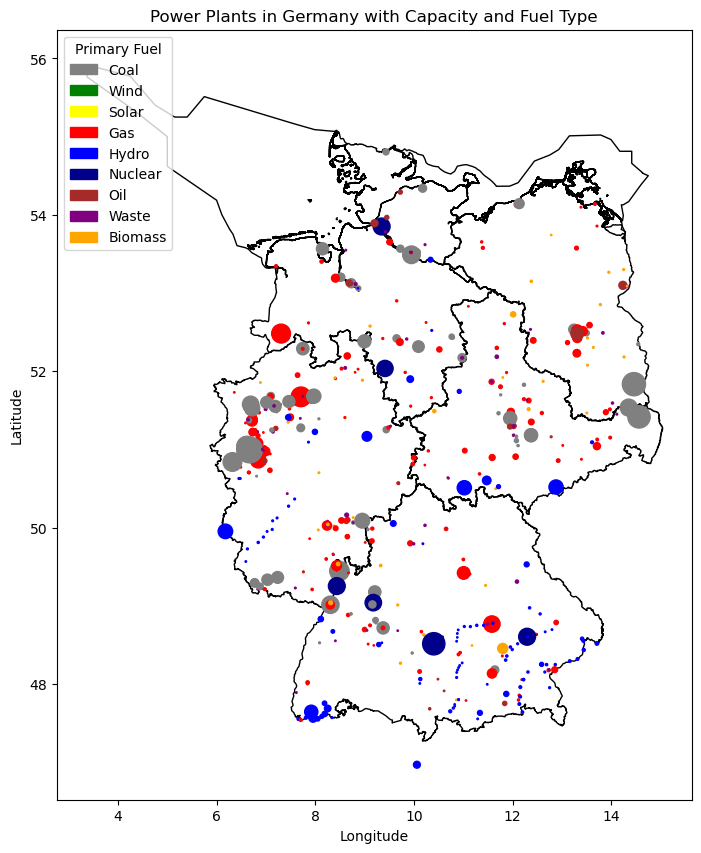

In [43]:
from matplotlib import patches
fig, ax = plt.subplots(figsize=(10, 10))

merged_gdf.plot(ax=ax, edgecolor='black', color="none")

fuel_colors = {
    'Coal': 'gray',
    'Wind': 'green',
    'Solar': 'yellow',
    'Gas': 'red',
    'Hydro': 'blue',
    'Nuclear': 'darkblue',
    'Oil': 'brown',       # Oil plants represented by brown
    'Waste': 'purple',    # Waste plants represented by purple
    'Biomass': 'orange',  # Biomass plants represented by orange
    # Add other fuel types and corresponding colors here if needed
}

plants_DE_regions['color'] = plants_DE_regions['primary_fuel'].map(fuel_colors)
plants_DE_regions.plot(ax=ax, color=plants_DE_regions['color'], markersize=plants_DE_regions['capacity_mw'] / 10, legend=True)

# 5. Customize the plot (optional)
plt.title("Power Plants in Germany with Capacity and Fuel Type")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

handles = [patches.Patch(color=color, label=fuel) for fuel, color in fuel_colors.items()]
ax.legend(handles=handles, title="Primary Fuel")

# 6. Show the plot
plt.show()


In [44]:
# For Plants capacities for each region
powerplants_per_region = plants_DE_regions.groupby(["group","primary_fuel"]).capacity_mw.sum().unstack().fillna(0)

display(powerplants_per_region)

primary_fuel,Biomass,Coal,Gas,Hydro,Nuclear,Oil,Waste
group,,,,,,,
1.0,76.8,5739.0,3343.00,365.4,4246.0,822.0,239.9
2.0,199.7,5864.0,2673.20,17.8,0.0,1212.5,170.9
3.0,291.7,5563.1,2116.25,2674.1,0.0,229.5,212.2
4.0,228.3,24664.3,11478.70,1174.7,0.0,231.1,679.4
5.0,858.8,5942.5,4819.10,4226.7,6925.0,356.1,286.4


### Technology and Cost Assumptions

In [45]:
year = 2045
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0,1])

In [46]:
# COnverting Costs to /MW
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

# Filling Missing Values

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

# Assigning Fuel Costs & CO2 Emission for Oil Plants
# Assignining Fuel Costs & CO2 emissions for OCGT and CCGT.

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]
costs.at["CCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

In [47]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

- Pick a projection for a year of your choice from the outputs directory. Calculate annuities with a discount rate of 7%. 
- Marginal cost include fuel costs and variable operation and maintenance costs (VOM).
- For the capital cost include the upfront investment costs as well as fixed operation and maintenance costs (FOM)

In [48]:
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]
annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [49]:
## Checking Costs for CCGT
display(costs.loc['CCGT'])


parameter
C in fuel                                  NaN
C stored                                   NaN
CO2 intensity                         0.198000
CO2 stored                                 NaN
FOM                                   3.275500
Motor size                                 NaN
VOM                                   4.285800
ammonia-input                              NaN
c_b                                   2.150000
c_v                                   0.150000
capacity                                   NaN
capture rate                               NaN
capture_rate                               NaN
carbondioxide-input                        NaN
carbondioxide-output                       NaN
commodity                                  NaN
compression-electricity-input              NaN
compression-heat-output                    NaN
discount rate                         0.070000
district heat surcharge                    NaN
district heat-input                        NaN
eff

# Load Time Series from the GEGIS dataset

In [50]:
fn="https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fgegis&files=load.csv"
load = pd.read_csv(fn, index_col="time")

In [51]:
load_DE = load["DE"]
display(load_DE)

time
2013-01-01 00:00:00    63196.455337
2013-01-01 01:00:00    61740.878964
2013-01-01 02:00:00    61639.372691
2013-01-01 03:00:00    61639.372691
2013-01-01 04:00:00    64320.673078
                           ...     
2013-12-31 19:00:00    83050.197866
2013-12-31 20:00:00    79062.389694
2013-12-31 21:00:00    75434.269439
2013-12-31 22:00:00    71970.997754
2013-12-31 23:00:00    67138.106749
Name: DE, Length: 8760, dtype: float64

In [52]:
load_DE = load_DE.to_frame()
# Ensure the index is a DateTime index
load_DE.index = pd.to_datetime(load_DE.index)

In [53]:
print(load_DE)

                               DE
time                             
2013-01-01 00:00:00  63196.455337
2013-01-01 01:00:00  61740.878964
2013-01-01 02:00:00  61639.372691
2013-01-01 03:00:00  61639.372691
2013-01-01 04:00:00  64320.673078
...                           ...
2013-12-31 19:00:00  83050.197866
2013-12-31 20:00:00  79062.389694
2013-12-31 21:00:00  75434.269439
2013-12-31 22:00:00  71970.997754
2013-12-31 23:00:00  67138.106749

[8760 rows x 1 columns]


In [54]:

# Define population for each state and assign region
population_data = [
    ["DEU.1_1", "Baden-Württemberg", 11339260, 5],
    ["DEU.2_1", "Bayern", 13435062, 5],
    ["DEU.3_1", "Berlin", 3782202, 2],
    ["DEU.4_1", "Brandenburg", 2581667, 2],
    ["DEU.5_1", "Bremen", 691703, 1],
    ["DEU.6_1", "Hamburg", 1910160, 1],
    ["DEU.7_1", "Hessen", 6420729, 4],
    ["DEU.8_1", "Mecklenburg-Vorpommern", 1629464, 2],
    ["DEU.9_1", "Niedersachsen", 8161981, 1],
    ["DEU.10_1", "Nordrhein-Westfalen", 18190422, 4],
    ["DEU.11_1", "Rheinland-Pfalz", 4174311, 4],
    ["DEU.12_1", "Saarland", 994424, 4],
    ["DEU.13_1", "Sachsen-Anhalt", 2180448, 3],
    ["DEU.14_1", "Sachsen", 4089467, 3],
    ["DEU.15_1", "Schleswig-Holstein", 2965691, 1],
    ["DEU.16_1", "Thüringen", 2122335, 3]
]

# Create DataFrame for population and group mapping
df_population = pd.DataFrame(population_data, columns=["DEU_Code", "State", "Population", "Region"])

# Calculate total population for each group (Region)
group_population = df_population.groupby("Region")["Population"].sum().reset_index()
group_population.columns = ["Region", "Total_Population"]

# Calculate total population of Germany
total_population = group_population["Total_Population"].sum()

# Define a new column as the proportion of total population
group_population["Population_Proportion"] = group_population["Total_Population"] / total_population
# Display the updated DataFrame
group_population = group_population.set_index("Region")
print(group_population)

        Total_Population  Population_Proportion
Region                                         
1               13729535               0.162155
2                7993333               0.094406
3                8392250               0.099118
4               29779886               0.351720
5               24774322               0.292601


In [55]:
# Loop through the regions and calculate the regional load
for region in group_population.index:
    proportion = group_population.loc[region, "Population_Proportion"]
    
    # Multiply the total load by the population proportion for each region
    load_DE[region] = load_DE["DE"] * proportion

# Drop the original "DE" column after distributing the load

# Fix: Replace the year with 2017
load_DE.index = load_DE.index.map(lambda x: x.replace(year=2021))

# Display the final DataFrame
ts_load = load_DE


In [56]:
load_region = ts_load.drop(columns="DE")

In [57]:
resolution = 3
load_region = load_region.resample(f"{resolution}h").mean()

In [58]:
display(load_region)

,1,2,3,4,5
time,,,,,
2021-01-01 00:00:00,10084.767608,5871.350029,6164.366890,21874.246267,18197.504870
2021-01-01 03:00:00,10760.523745,6264.775140,6577.426359,23339.987147,19416.876111
2021-01-01 06:00:00,13783.274376,8024.620056,8425.098474,29896.448759,24871.292261
2021-01-01 09:00:00,14126.242829,8224.296232,8634.739733,30640.360438,25490.163249
2021-01-01 12:00:00,14110.939472,8215.386620,8625.385476,30607.166872,25462.549037
...,...,...,...,...,...
2021-12-31 09:00:00,13680.308729,7964.673473,8362.160185,29673.112337,24685.495431
2021-12-31 12:00:00,13419.305309,7812.717325,8202.620480,29106.985946,24214.526620
2021-12-31 15:00:00,13603.301186,7919.839694,8315.088922,29506.080034,24546.538819


### Transmission Lines

Assume costs of 600€/MW/km and a
 length of 1.5 times the crow-fly distance between the regions’ representative points.

In [59]:
# Ensure 'geometry' column contains valid geometries
merged_gdf_points = merged_gdf
merged_gdf_points["representative_point"] = merged_gdf_points["geometry"].representative_point()
print(merged_gdf_points)

                                                geometry  \
group                                                      
1      MULTIPOLYGON (((6.77028 53.61653, 6.77083 53.6...   
2      MULTIPOLYGON (((12.28311 52.22825, 12.28353 52...   
3      POLYGON ((11.25267 50.26939, 11.2523 50.26902,...   
4      MULTIPOLYGON (((7.19668 49.12022, 7.19647 49.1...   
5      MULTIPOLYGON (((8.67649 47.69794, 8.67512 47.7...   
6      MULTIPOLYGON (((14.11579 53.86848, 14.12778 53...   

            representative_point  
group                             
1         POINT (9.19726 53.174)  
2      POINT (12.98466 52.92134)  
3       POINT (11.87083 51.6066)  
4        POINT (7.9866 50.74848)  
5      POINT (10.90029 48.91795)  
6       POINT (7.08933 54.39532)  


In [60]:
# Converting Points to EPSG:3857
# EPSG:3857 is commonly used in web mapping (Google Maps, OpenStreetMap) because it is a projection system based on meters, rather than geographic coordinates (latitude/longitude)

merged_gdf_points["representative_point"] = merged_gdf_points["representative_point"].to_crs(3857)


In [61]:
distances = pd.concat({
    k: merged_gdf_points["representative_point"].distance(p) for k, p in merged_gdf_points["representative_point"].items()
}, axis=1)

# Step 2: Convert the distances from meters to kilometers
distances = distances.div(1e3)  # Convert from meters to kilometers

# Step 3: Multiply distances by 1.5 (to get 1.5 times the crow-fly distance)
distances = distances * 1.5

dict = {1: 'Region 1',
        2: 'Region 2',
        3: 'Region 3',
        4: 'Region 4',
        5: 'Region 5',
        6: 'Region 6'}

distances.rename(columns=dict, inplace=True)
distances.rename(index=dict, inplace=True)
distances


,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6
group,,,,,,
Region 1,0.000000,636.300297,619.087549,687.862883,1166.633852,493.008009
Region 2,636.300297,0.000000,404.083481,1020.510841,1116.880253,1068.449951
Region 3,619.087549,404.083481,0.000000,687.682916,720.978540,1112.081032
Region 4,687.862883,1020.510841,687.682916,0.000000,679.223065,1013.823838
Region 5,1166.633852,1116.880253,720.978540,679.223065,0.000000,1607.930036
Region 6,493.008009,1068.449951,1112.081032,1013.823838,1607.930036,0.000000


# PyPSA MODELLING

In [62]:
import gurobipy as gp


In [63]:
from pyomo.environ import SolverFactory
print(SolverFactory('gurobi').available())


True


In [64]:
import pypsa

In [65]:
n = pypsa.Network()

In [66]:
n.set_snapshots(load_region.index)
n.snapshot_weightings.loc[:,:] = resolution
n.snapshot_weightings.head(3)

,objective,stores,generators
snapshot,,,
2021-01-01 00:00:00,3.0,3.0,3.0
2021-01-01 03:00:00,3.0,3.0,3.0
2021-01-01 06:00:00,3.0,3.0,3.0


In [67]:
## add busses
n.add("Bus", "Region 1", y=9.19 , x=53.17)
n.add("Bus", "Region 2", y=12.98, x=52.92)
n.add("Bus", "Region 3", y=11.87, x=51.60)
n.add("Bus", "Region 4", y=7.98, x=50.74)
n.add("Bus", "Region 5", y=10.90, x=48.91)
n.add("Bus", "Region 6", y=7.08, x=54.39)

Index(['Region 6'], dtype='object')

In [68]:
#add generators
carriers = [
    "onwind",
    "offwind",
    "solar",
    "OCGT",
    "biomass",
    "coal",
    "nuclear",
    "oil",
    "hydrogen storage underground",
    "battery storage",
    "hydro"
]

colors = [
    "#70a494",  # Greenish Teal #Onwind
    "#2a5674",  # Deep Blue  #offwind
    "#f4a261",  # Warm Orange  #solar
    "#e76f51",  # Burnt Red  #OCGT
    "#9b7653",  # Earthy Brown biomass
    "#4e4e50",  # Dark Gray # Coal
    "#ffcc00",  # Bright Yellow  #Nuclear
    "#343a40",  # Blackish Gray  #Oil
    "#6abedb",  # Light Cyan  #hydrogen
    "#8d99ae",  # Muted Blue-Gray #batter
    "#1e3a8a", # hydro
]

In [69]:
co2_emissions = [costs.at[c, "CO2 intensity"] for c in carriers]

n.add(
    "Carrier",
    carriers,
    color= colors,
    co2_emissions=co2_emissions,
    overwrite=True
)


Index(['onwind', 'offwind', 'solar', 'OCGT', 'biomass', 'coal', 'nuclear',
       'oil', 'hydrogen storage underground', 'battery storage', 'hydro'],
      dtype='object')

In [70]:
n.add(
    "Carrier",
    "HVAC",
    color = "brown",
    co2_emissions = 0
)

Index(['HVAC'], dtype='object')

In [71]:
## Onshore wind

for r in range(1,6):
    n.add(
        "Generator",
        f"onwind_region_{r}",
        bus=f"Region {r}",
        carrier="onwind",
        p_max_pu=time_series_onshore_wind[r],
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
        p_nom_max=onwind_area.loc[r, "p_nom_max"],
    )

In [72]:
## Solar

for r in range(1,6):
    n.add(
        "Generator",
        f"solar_pv_region_{r}",
        bus=f"Region {r}",
        carrier="solar",
        p_max_pu=time_series_solar[r],
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
        p_nom_max=solar_area.loc[r, "p_nom_max"],
    )

In [73]:
### off wind

n.add(
    "Generator",
    "Offshore_region_6",
    bus="Region 6",
    carrier="offwind",
    p_max_pu=time_series_offshore_wind[6],
    capital_cost=costs.at["offwind", "capital_cost"],
    marginal_cost=costs.at["offwind", "marginal_cost"],
    efficiency=costs.at["offwind", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=p_nom_max_offwind
)

Index(['Offshore_region_6'], dtype='object')

In [74]:
#add coal

for r in range(1,6):
    n.add(
        "Generator",
        f"coal_region_{r}",
        bus=f"Region {r}",
        carrier="coal",
        p_nom=powerplants_per_region.loc[r, "Coal"],
        capital_cost=0,
        marginal_cost=costs.at["coal", "marginal_cost"],
        efficiency=costs.at["coal", "efficiency"],
        p_nom_extendable=False,
    )

In [75]:
## Add Oil

for r in range(1,6):
    n.add(
        "Generator",
        f"Oil_region_{r}",
        bus=f"Region {r}",
        carrier="oil",
        p_nom=powerplants_per_region.loc[r, "Oil"],
        capital_cost=0,
        marginal_cost=costs.at["oil", "marginal_cost"],
        efficiency=costs.at["oil", "efficiency"],
        p_nom_extendable=False,
    )


In [76]:
## Add Biomass

for r in range(1,6):
    n.add(
        "Generator",
        f"Biomass_region_{r}",
        bus=f"Region {r}",
        carrier="biomass",
        p_nom=powerplants_per_region.loc[r, "Biomass"],
        capital_cost=0,
        marginal_cost=costs.at["biomass", "marginal_cost"],
        efficiency=costs.at["biomass", "efficiency"],
        p_nom_extendable=False,
    )

In [77]:
### Add Nuclear

for r in range(1,6):
    n.add(
        "Generator",
        f"Nuclear_region_{r}",
        bus=f"Region {r}",
        carrier="nuclear",
        p_nom=powerplants_per_region.loc[r, "Nuclear"],
        capital_cost=0,
        marginal_cost=costs.at["nuclear", "marginal_cost"],
        efficiency=costs.at["nuclear", "efficiency"],
        p_nom_extendable=False,
    )

In [78]:
# Step 1: Check if there are any rows where 'primary_fuel' is 'hydro' and verify the column names
hydro_plants = plants_DE_regions[plants_DE_regions["primary_fuel"] == "Hydro"]

# Step 3: Group by 'group' and 'primary_fuel', sum the 'estimated_generation_gwh_2017'
estimated_generation_2017 = hydro_plants.groupby(["group", "primary_fuel"])["estimated_generation_gwh_2017"] \
    .sum() \
    .unstack() \
    .fillna(0)  # Fill any missing values with 0

# Step 4: Print the final result
print("\nEstimated Generation (GWh) for Hydro in 2017 (Group by 'group'):")
print(estimated_generation_2017)



Estimated Generation (GWh) for Hydro in 2017 (Group by 'group'):
primary_fuel     Hydro
group                 
1.0             826.68
2.0              60.04
3.0            5619.33
4.0            2688.04
5.0           11520.31


In [79]:
estimated_generation_mwh_2017 = estimated_generation_2017['Hydro'] * 1000

# Rated capacity from powerplants_per_region (Hydro capacity in MW)
hydro_capacity_mw = powerplants_per_region['Hydro']

# Calculate the capacity factor (p_max_pu) as the ratio of generation to capacity, normalized by hours in a year (8760)
p_max_pu_hydro = estimated_generation_mwh_2017 / (hydro_capacity_mw * 8760)

# Print the calculated p_max_pu to verify
print("Capacity Factor (p_max_pu) for Hydro plants in each group:")
print(p_max_pu_hydro)

Capacity Factor (p_max_pu) for Hydro plants in each group:
group
1.0    0.258265
2.0    0.385050
3.0    0.239885
4.0    0.261219
5.0    0.311142
Name: Hydro, dtype: float64


In [80]:
## Add Hydro Generators
for r in range(1,6):
    # Add the Hydro Generator for each group using the calculated p_max_pu
    n.add(
        "Generator",
        f"Hydro_region_{r}",
        bus=f"Region {r}",
        carrier="hydro",  # Define the carrier as hydro
        p_max_pu=p_max_pu_hydro[r],  # Use the calculated capacity factor (p_max_pu)
        capital_cost=0,  
        marginal_cost=costs.at["hydro", "marginal_cost"],  # Use the marginal cost for hydro if available
        efficiency=costs.at["hydro", "efficiency"],  # Use efficiency for hydro
        p_nom=hydro_capacity_mw[r],  # Set the rated capacity of the plant
        p_nom_extendable=False  # Hydro plants typically have fixed capacity
    )

In [81]:
## Add Loads

for r in range(1,6):
    n.add(
        "Load",
        f"load_region_{r}",
        bus=f"Region {r}",
        p_set=load_region[r]
    )

In [82]:
transmission = pd.DataFrame({
    'Start': ['Region 1', 'Region 1', 'Region 1', 'Region 1',
              'Region 2', "Region 2", "Region 3", 'Region 3',
              'Region 4'],
    'End':   ['Region 2', 'Region 3', 'Region 4', 'Region 6',
              'Region 3', "Region 6",'Region 4', 'Region 5',
              'Region 5']
})


In [83]:
print(transmission)

      Start       End
0  Region 1  Region 2
1  Region 1  Region 3
2  Region 1  Region 4
3  Region 1  Region 6
4  Region 2  Region 3
5  Region 2  Region 6
6  Region 3  Region 4
7  Region 3  Region 5
8  Region 4  Region 5


In [84]:
for _, row in transmission.iterrows():
    start_region = row['Start']
    end_region = row['End']
    distance = distances.loc[start_region, end_region]
    
    n.add(
        "Link",
        f"{start_region}-{end_region}",
        bus0=start_region,
        bus1=end_region,
        efficiency=1,
        marginal_cost=0,
        p_min_pu=-1,
        length=distance,
        capital_cost=600 * distance,
        p_nom_extendable=True,
        carrier="HVAC",
    )

In [85]:
#add battery storage

for r in range(1,7):
    n.add(
        "StorageUnit",
        f"battery storage region {r}",
        bus=f'Region {r}',
        carrier="battery storage",
        max_hours=6,#given
        capital_cost=costs.at["battery inverter", "capital_cost"] + 6 * costs.at["battery storage", "capital_cost"],
        efficiency_store=costs.at["battery inverter", "efficiency"],
        efficiency_dispatch=costs.at["battery inverter", "efficiency"],
        p_nom_extendable=True,
        cyclic_state_of_charge=True,
    )
    

In [86]:
#add hydrogen storage

capital_costs = (
    costs.at["electrolysis", "capital_cost"]
    + costs.at["fuel cell", "capital_cost"]
    + 300 * costs.at["hydrogen storage underground", "capital_cost"]
)

for r in range(1,7):
    n.add(
        "StorageUnit",
        f"hydrogen storage underground region {r}",
        bus=f'Region {r}',
        carrier="hydrogen storage underground",
        max_hours=300,
        capital_cost=capital_costs,
        efficiency_store=costs.at["electrolysis", "efficiency"],
        efficiency_dispatch=costs.at["fuel cell", "efficiency"],
        p_nom_extendable=True,
        cyclic_state_of_charge=True,
    )

In [87]:
n

PyPSA Network
Components:
 - Bus: 6
 - Carrier: 12
 - Generator: 36
 - Link: 9
 - Load: 5
 - StorageUnit: 12
Snapshots: 2920

# Optimization Model Runs

In [88]:
n.consistency_check()

Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')


## Without CO2 constraint

In [172]:
n.optimize(solver_name="gurobi")

Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')
Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')
c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\linopy\common.py:147: UserWarning:

coords for dimension(s) ['Generator'] is not aligned with the pandas object. Previously, the indexes of the pandas were ignored and overwritten in these cases. Now, the pandas object's coordinates are taken considered for alignment.

INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2618630


INFO:gurobipy:Set parameter LicenseID to value 2618630


...

Solved in 54989 iterations and 46.02 seconds (12.51 work units)


INFO:gurobipy:Solved in 54989 iterations and 46.02 seconds (12.51 work units)


Optimal objective  2.476491556e+10


INFO:gurobipy:Optimal objective  2.476491556e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 236552 primals, 525679 duals
Objective: 2.48e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [173]:
n.objective

24764915560.986

In [106]:
n.objective / 1e9

24.764915560986

The optimised capacities in GW:

In [107]:
display(n.generators.p_nom_opt.div(1e3)) # GW

Generator
onwind_region_1       7.002248
onwind_region_2       4.095384
onwind_region_3       3.541167
onwind_region_4       7.251065
onwind_region_5      10.381170
solar_pv_region_1    19.901992
solar_pv_region_2    11.353274
solar_pv_region_3    17.533207
solar_pv_region_4    56.773001
solar_pv_region_5    91.890638
Offshore_region_6     0.000000
coal_region_1         5.739000
coal_region_2         5.864000
coal_region_3         5.563100
coal_region_4        24.664300
coal_region_5         5.942500
Oil_region_1          0.822000
Oil_region_2          1.212500
Oil_region_3          0.229500
Oil_region_4          0.231100
Oil_region_5          0.356100
Biomass_region_1      0.076800
Biomass_region_2      0.199700
Biomass_region_3      0.291700
Biomass_region_4      0.228300
Biomass_region_5      0.858800
Nuclear_region_1      4.246000
Nuclear_region_2      0.000000
Nuclear_region_3      0.000000
Nuclear_region_4      0.000000
Nuclear_region_5      6.925000
Hydro_region_1        0.36540

The total energy generation by technology in GW:

In [108]:
n.snapshot_weightings.generators @ n.generators_t.p.div(1e6)  # TWh

Generator
onwind_region_1       15.545306
onwind_region_2        8.794092
onwind_region_3        5.667369
onwind_region_4       11.457791
onwind_region_5       10.408345
solar_pv_region_1     22.001567
solar_pv_region_2     12.660970
solar_pv_region_3     19.571447
solar_pv_region_4     62.856561
solar_pv_region_5    106.099449
Offshore_region_6      0.000000
coal_region_1         26.542353
coal_region_2         33.268424
coal_region_3         29.118479
coal_region_4        137.961809
coal_region_5         17.360680
Oil_region_1           0.278147
Oil_region_2           0.453202
Oil_region_3           0.125471
Oil_region_4           0.101673
Oil_region_5           0.366670
Biomass_region_1       0.590145
Biomass_region_2       1.707775
Biomass_region_3       2.330627
Biomass_region_4       1.877232
Biomass_region_5       3.778229
Nuclear_region_1      35.559780
Nuclear_region_2       0.000000
Nuclear_region_3       0.000000
Nuclear_region_4       0.000000
Nuclear_region_5      44.78973

In [109]:
n.links.p_nom_opt

Link
Region 1-Region 2      0.000000
Region 1-Region 3    151.366486
Region 1-Region 4     60.479364
Region 1-Region 6      0.000000
Region 2-Region 3    301.922684
Region 2-Region 6      0.000000
Region 3-Region 4      0.000000
Region 3-Region 5    503.756160
Region 4-Region 5    706.650927
Name: p_nom_opt, dtype: float64

In [110]:
n.storage_units.p_nom_opt

StorageUnit
battery storage region 1                  3041.583338
battery storage region 2                  1616.164142
battery storage region 3                  3409.883693
battery storage region 4                  7081.053297
battery storage region 5                 22676.746873
battery storage region 6                     0.000000
hydrogen storage underground region 1     1291.474385
hydrogen storage underground region 2        0.000000
hydrogen storage underground region 3      523.263084
hydrogen storage underground region 4      992.590091
hydrogen storage underground region 5     2698.454928
hydrogen storage underground region 6        0.000000
Name: p_nom_opt, dtype: float64

In [174]:
n.export_to_netcdf("n_no_constraint_gurobi.nc")

INFO:pypsa.io:Exported network 'n_no_constraint_gurobi.nc' contains: loads, buses, storage_units, generators, carriers, links


<xarray.Dataset> Size: 3MB
Dimensions:                               (snapshots: 2920,
                                           investment_periods: 0, loads_i: 5,
                                           loads_t_p_set_i: 5, loads_t_p_i: 5,
                                           buses_i: 6, buses_t_p_i: 5,
                                           buses_t_marginal_price_i: 6,
                                           storage_units_i: 12,
                                           ...
                                           storage_units_t_state_of_charge_i: 12,
                                           generators_i: 36,
                                           generators_t_p_max_pu_i: 11,
                                           generators_t_p_i: 32,
                                           carriers_i: 12, links_i: 9,
                                           links_t_p0_i: 5, links_t_p1_i: 5)
Coordinates: (12/20)
  * snapshots                             (snapshots) int64 23kB 0 1 ... 2919
  * investment_periods                    (investment_periods) int64 0B 
  * loads_i                               (loads_i) object 40B 'load_region_1...
  * loads_t_p_set_i                       (loads_t_p_set_i) object 40B 'load_...
  * loads_t_p_i                           (loads_t_p_i) object 40B 'load_regi...
  * buses_i                               (buses_i) object 48B 'Region 1' ......
    ...                                    ...
  * generators_t_p_max_pu_i               (generators_t_p_max_pu_i) object 88B ...
  * generators_t_p_i                      (generators_t_p_i) object 256B 'onw...
  * carriers_i                            (carriers_i) object 96B 'HVAC' ... ...
  * links_i                               (links_i) object 72B 'Region 1-Regi...
  * links_t_p0_i                          (links_t_p0_i) object 40B 'Region 1...
  * links_t_p1_i                          (links_t_p1_i) object 40B 'Region 1...
Data variables: (12/61)
    snapshots_snapshot                    (snapshots) datetime64[ns] 23kB 202...
    snapshots_objective                   (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_stores                      (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_generators                  (snapshots) float64 23kB 3.0 ... 3.0
    investment_periods_objective          (investment_periods) object 0B 
    investment_periods_years              (investment_periods) object 0B 
    ...                                    ...
    links_min_down_time                   (links_i) int64 72B 0 0 0 0 0 0 0 0 0
    links_up_time_before                  (links_i) int64 72B 1 1 1 1 1 1 1 1 1
    links_down_time_before                (links_i) int64 72B 0 0 0 0 0 0 0 0 0
    links_p_nom_opt                       (links_i) float64 72B 0.0 ... 706.7
    links_t_p0                            (snapshots, links_t_p0_i) float64 117kB ...
    links_t_p1                            (snapshots, links_t_p1_i) float64 117kB ...
Attributes:
    network__linearized_uc:      0
    network__multi_invest:       0
    network_name:                
    network_objective:           24764915560.986
    network_objective_constant:  0.0
    network_pypsa_version:       0.31.0
    network_srid:                4326
    crs:                         {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Worl...
    meta:                        {}

## CO2 Constraint

In [179]:
no_co2_model = pypsa.Network("n_no_constraint_gurobi.nc")

INFO:pypsa.io:Imported network n_no_constraint_gurobi.nc has buses, carriers, generators, links, loads, storage_units


In [180]:
no_co2_model.add(
    "GlobalConstraint",
    "CO2Limit",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant=0,
)

Index(['CO2Limit'], dtype='object')

In [181]:
no_co2_model.optimize(solver_name="gurobi")

Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')
Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')
c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\linopy\common.py:147: UserWarning:

coords for dimension(s) ['Generator'] is not aligned with the pandas object. Previously, the indexes of the pandas were ignored and overwritten in these cases. Now, the pandas object's coordinates are taken considered for alignment.

INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2618630


INFO:gurobipy:Set parameter LicenseID to value 2618630


...

Solved in 52659 iterations and 58.09 seconds (13.77 work units)


INFO:gurobipy:Solved in 52659 iterations and 58.09 seconds (13.77 work units)


Optimal objective  8.016600160e+10


INFO:gurobipy:Optimal objective  8.016600160e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 236552 primals, 525680 duals
Objective: 8.02e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [182]:
no_co2_model.snapshot_weightings.generators @ no_co2_model.generators_t.p.div(1e6)  # TWh

Generator
Biomass_region_1       0.079488
Biomass_region_2       0.241420
Biomass_region_3       0.353540
Biomass_region_4       0.271866
Biomass_region_5       1.253400
Hydro_region_1         0.826680
Hydro_region_2         0.060040
Hydro_region_3         5.619330
Hydro_region_4         2.688040
Hydro_region_5        11.520310
Nuclear_region_1       5.841497
Nuclear_region_2       0.000000
Nuclear_region_3       0.000000
Nuclear_region_4       0.000000
Nuclear_region_5      15.649166
Offshore_region_6    167.130908
Oil_region_1           0.000000
Oil_region_2           0.000000
Oil_region_3           0.000000
Oil_region_4           0.000000
Oil_region_5           0.000000
coal_region_1          0.000000
coal_region_2          0.000000
coal_region_3          0.000000
coal_region_4          0.000000
coal_region_5          0.000000
onwind_region_1        9.672777
onwind_region_2        9.220882
onwind_region_3        9.457295
onwind_region_4        4.563084
onwind_region_5        6.42660

In [183]:
no_co2_model.export_to_netcdf("no_CO2_model_gurobi.nc")

INFO:pypsa.io:Exported network 'no_CO2_model_gurobi.nc' contains: loads, buses, storage_units, generators, global_constraints, carriers, links


<xarray.Dataset> Size: 3MB
Dimensions:                               (snapshots: 2920,
                                           investment_periods: 0, loads_i: 5,
                                           loads_t_p_set_i: 5, loads_t_p_i: 5,
                                           buses_i: 6, buses_t_p_i: 6,
                                           buses_t_marginal_price_i: 6,
                                           storage_units_i: 12,
                                           ...
                                           generators_i: 36,
                                           generators_t_p_max_pu_i: 11,
                                           generators_t_p_i: 23,
                                           global_constraints_i: 1,
                                           carriers_i: 12, links_i: 9,
                                           links_t_p0_i: 7, links_t_p1_i: 7)
Coordinates: (12/21)
  * snapshots                             (snapshots) int64 23kB 0 1 ... 2919
  * investment_periods                    (investment_periods) int64 0B 
  * loads_i                               (loads_i) object 40B 'load_region_1...
  * loads_t_p_set_i                       (loads_t_p_set_i) object 40B 'load_...
  * loads_t_p_i                           (loads_t_p_i) object 40B 'load_regi...
  * buses_i                               (buses_i) object 48B 'Region 1' ......
    ...                                    ...
  * generators_t_p_i                      (generators_t_p_i) object 184B 'Bio...
  * global_constraints_i                  (global_constraints_i) object 8B 'C...
  * carriers_i                            (carriers_i) object 96B 'HVAC' ... ...
  * links_i                               (links_i) object 72B 'Region 1-Regi...
  * links_t_p0_i                          (links_t_p0_i) object 56B 'Region 1...
  * links_t_p1_i                          (links_t_p1_i) object 56B 'Region 1...
Data variables: (12/52)
    snapshots_snapshot                    (snapshots) datetime64[ns] 23kB 202...
    snapshots_objective                   (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_generators                  (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_stores                      (snapshots) float64 23kB 3.0 ... 3.0
    investment_periods_objective          (investment_periods) float64 0B 
    investment_periods_years              (investment_periods) float64 0B 
    ...                                    ...
    links_p_min_pu                        (links_i) float64 72B -1.0 ... -1.0
    links_capital_cost                    (links_i) float64 72B 3.818e+05 ......
    links_length                          (links_i) float64 72B 636.3 ... 679.2
    links_p_nom_opt                       (links_i) float64 72B 0.0 ... 1.106...
    links_t_p0                            (snapshots, links_t_p0_i) float64 164kB ...
    links_t_p1                            (snapshots, links_t_p1_i) float64 164kB ...
Attributes:
    network__linearized_uc:      0
    network__multi_invest:       0
    network_name:                
    network_objective:           80166001604.90956
    network_objective_constant:  0.0
    network_pypsa_version:       0.31.0
    network_srid:                4326
    crs:                         {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Worl...
    meta:                        {}

# Hydrogen Cost 75% Reduction

In [199]:
electrolysis_75 = pypsa.Network("no_CO2_model_gurobi.nc")

INFO:pypsa.io:Imported network no_CO2_model_gurobi.nc has buses, carriers, generators, global_constraints, links, loads, storage_units


In [ ]:
#add hydrogen storage 0.75 of Capital Costs

capital_costs = (
    costs.at["electrolysis", "capital_cost"]
    + costs.at["fuel cell", "capital_cost"]
    + 300 * costs.at["hydrogen storage underground", "capital_cost"]
)

for r in range(1,7):
    electrolysis_75.add(
        "StorageUnit",
        f"hydrogen storage underground region {r}",
        bus=f'Region {r}',
        carrier="hydrogen storage underground",
        max_hours=300,
        capital_cost=capital_costs*0.75,
        efficiency_store=costs.at["electrolysis", "efficiency"],
        efficiency_dispatch=costs.at["fuel cell", "efficiency"],
        p_nom_extendable=True,
        cyclic_state_of_charge=True,
         
    )

In [208]:
no_co2_model_data.storage_units.capital_cost

StorageUnit
battery storage region 1                  55860.863544
battery storage region 2                  55860.863544
battery storage region 3                  55860.863544
battery storage region 4                  55860.863544
battery storage region 5                  55860.863544
battery storage region 6                  55860.863544
hydrogen storage underground region 1    346557.558184
hydrogen storage underground region 2    346557.558184
hydrogen storage underground region 3    346557.558184
hydrogen storage underground region 4    346557.558184
hydrogen storage underground region 5    346557.558184
hydrogen storage underground region 6    346557.558184
Name: capital_cost, dtype: float64

In [207]:
electrolysis_75.storage_units.capital_cost

StorageUnit
battery storage region 1                  55860.863544
battery storage region 2                  55860.863544
battery storage region 3                  55860.863544
battery storage region 4                  55860.863544
battery storage region 5                  55860.863544
battery storage region 6                  55860.863544
hydrogen storage underground region 1    259918.168638
hydrogen storage underground region 2    259918.168638
hydrogen storage underground region 3    259918.168638
hydrogen storage underground region 4    259918.168638
hydrogen storage underground region 5    259918.168638
hydrogen storage underground region 6    259918.168638
Name: capital_cost, dtype: float64

In [209]:
electrolysis_75.optimize(solver_name="gurobi")

Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')
Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')
c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\linopy\common.py:147: UserWarning:

coords for dimension(s) ['Generator'] is not aligned with the pandas object. Previously, the indexes of the pandas were ignored and overwritten in these cases. Now, the pandas object's coordinates are taken considered for alignment.

INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2618630


INFO:gurobipy:Set parameter LicenseID to value 2618630


...

Solved in 143531 iterations and 78.28 seconds (21.32 work units)


INFO:gurobipy:Solved in 143531 iterations and 78.28 seconds (21.32 work units)


Optimal objective  7.642235906e+10


INFO:gurobipy:Optimal objective  7.642235906e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 236552 primals, 525680 duals
Objective: 7.64e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [211]:
electrolysis_75.export_to_netcdf("sensitivity_75_hydrogen.nc")

INFO:pypsa.io:Exported network 'sensitivity_75_hydrogen.nc' contains: loads, buses, storage_units, generators, global_constraints, carriers, links


<xarray.Dataset> Size: 3MB
Dimensions:                               (snapshots: 2920,
                                           investment_periods: 0, loads_i: 5,
                                           loads_t_p_set_i: 5, loads_t_p_i: 5,
                                           buses_i: 6, buses_t_p_i: 6,
                                           buses_t_marginal_price_i: 6,
                                           storage_units_i: 12,
                                           ...
                                           generators_i: 36,
                                           generators_t_p_max_pu_i: 11,
                                           generators_t_p_i: 23,
                                           global_constraints_i: 1,
                                           carriers_i: 12, links_i: 9,
                                           links_t_p0_i: 8, links_t_p1_i: 8)
Coordinates: (12/21)
  * snapshots                             (snapshots) int64 23kB 0 1 ... 2919
  * investment_periods                    (investment_periods) int64 0B 
  * loads_i                               (loads_i) object 40B 'load_region_1...
  * loads_t_p_set_i                       (loads_t_p_set_i) object 40B 'load_...
  * loads_t_p_i                           (loads_t_p_i) object 40B 'load_regi...
  * buses_i                               (buses_i) object 48B 'Region 1' ......
    ...                                    ...
  * generators_t_p_i                      (generators_t_p_i) object 184B 'Bio...
  * global_constraints_i                  (global_constraints_i) object 8B 'C...
  * carriers_i                            (carriers_i) object 96B 'HVAC' ... ...
  * links_i                               (links_i) object 72B 'Region 1-Regi...
  * links_t_p0_i                          (links_t_p0_i) object 64B 'Region 1...
  * links_t_p1_i                          (links_t_p1_i) object 64B 'Region 1...
Data variables: (12/63)
    snapshots_snapshot                    (snapshots) datetime64[ns] 23kB 202...
    snapshots_objective                   (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_generators                  (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_stores                      (snapshots) float64 23kB 3.0 ... 3.0
    investment_periods_objective          (investment_periods) float64 0B 
    investment_periods_years              (investment_periods) float64 0B 
    ...                                    ...
    links_min_down_time                   (links_i) int64 72B 0 0 0 0 0 0 0 0 0
    links_up_time_before                  (links_i) int64 72B 1 1 1 1 1 1 1 1 1
    links_down_time_before                (links_i) int64 72B 0 0 0 0 0 0 0 0 0
    links_p_nom_opt                       (links_i) float64 72B 0.0 ... 859.9
    links_t_p0                            (snapshots, links_t_p0_i) float64 187kB ...
    links_t_p1                            (snapshots, links_t_p1_i) float64 187kB ...
Attributes:
    network__linearized_uc:      0
    network__multi_invest:       0
    network_name:                
    network_objective:           76422359055.18784
    network_objective_constant:  0.0
    network_pypsa_version:       0.31.0
    network_srid:                4326
    crs:                         {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Worl...
    meta:                        {}

# Hydrogen Cost 50% Reduction

In [212]:
electrolysis_50 = pypsa.Network("no_CO2_model_gurobi.nc")

INFO:pypsa.io:Imported network no_CO2_model_gurobi.nc has buses, carriers, generators, global_constraints, links, loads, storage_units


In [214]:
#add hydrogen storage 0.50 of Capital Costs

capital_costs = (
    costs.at["electrolysis", "capital_cost"]
    + costs.at["fuel cell", "capital_cost"]
    + 300 * costs.at["hydrogen storage underground", "capital_cost"]
)

for r in range(1,7):
    electrolysis_50.add(
        "StorageUnit",
        f"hydrogen storage underground region {r}",
        bus=f'Region {r}',
        carrier="hydrogen storage underground",
        max_hours=300,
        capital_cost=capital_costs*0.5,
        efficiency_store=costs.at["electrolysis", "efficiency"],
        efficiency_dispatch=costs.at["fuel cell", "efficiency"],
        p_nom_extendable=True,
        cyclic_state_of_charge=True,
        overwrite=True
    )

In [215]:
electrolysis_50.optimize(solver_name="gurobi")

Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')
Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')
c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\linopy\common.py:147: UserWarning:

coords for dimension(s) ['Generator'] is not aligned with the pandas object. Previously, the indexes of the pandas were ignored and overwritten in these cases. Now, the pandas object's coordinates are taken considered for alignment.

INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2618630


INFO:gurobipy:Set parameter LicenseID to value 2618630


...

Solved in 39856 iterations and 63.06 seconds (19.72 work units)


INFO:gurobipy:Solved in 39856 iterations and 63.06 seconds (19.72 work units)


Optimal objective  7.088591079e+10


INFO:gurobipy:Optimal objective  7.088591079e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 236552 primals, 525680 duals
Objective: 7.09e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [216]:
electrolysis_50.export_to_netcdf("sensitivity_50_hydrogen.nc")

INFO:pypsa.io:Exported network 'sensitivity_50_hydrogen.nc' contains: loads, buses, storage_units, generators, global_constraints, carriers, links


<xarray.Dataset> Size: 3MB
Dimensions:                               (snapshots: 2920,
                                           investment_periods: 0, loads_i: 5,
                                           loads_t_p_set_i: 5, loads_t_p_i: 5,
                                           buses_i: 6, buses_t_p_i: 6,
                                           buses_t_marginal_price_i: 6,
                                           storage_units_i: 12,
                                           ...
                                           generators_i: 36,
                                           generators_t_p_max_pu_i: 11,
                                           generators_t_p_i: 22,
                                           global_constraints_i: 1,
                                           carriers_i: 12, links_i: 9,
                                           links_t_p0_i: 9, links_t_p1_i: 9)
Coordinates: (12/21)
  * snapshots                             (snapshots) int64 23kB 0 1 ... 2919
  * investment_periods                    (investment_periods) int64 0B 
  * loads_i                               (loads_i) object 40B 'load_region_1...
  * loads_t_p_set_i                       (loads_t_p_set_i) object 40B 'load_...
  * loads_t_p_i                           (loads_t_p_i) object 40B 'load_regi...
  * buses_i                               (buses_i) object 48B 'Region 1' ......
    ...                                    ...
  * generators_t_p_i                      (generators_t_p_i) object 176B 'Bio...
  * global_constraints_i                  (global_constraints_i) object 8B 'C...
  * carriers_i                            (carriers_i) object 96B 'HVAC' ... ...
  * links_i                               (links_i) object 72B 'Region 1-Regi...
  * links_t_p0_i                          (links_t_p0_i) object 72B 'Region 1...
  * links_t_p1_i                          (links_t_p1_i) object 72B 'Region 1...
Data variables: (12/63)
    snapshots_snapshot                    (snapshots) datetime64[ns] 23kB 202...
    snapshots_objective                   (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_generators                  (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_stores                      (snapshots) float64 23kB 3.0 ... 3.0
    investment_periods_objective          (investment_periods) float64 0B 
    investment_periods_years              (investment_periods) float64 0B 
    ...                                    ...
    links_min_down_time                   (links_i) int64 72B 0 0 0 0 0 0 0 0 0
    links_up_time_before                  (links_i) int64 72B 1 1 1 1 1 1 1 1 1
    links_down_time_before                (links_i) int64 72B 0 0 0 0 0 0 0 0 0
    links_p_nom_opt                       (links_i) float64 72B 37.98 ... 636.6
    links_t_p0                            (snapshots, links_t_p0_i) float64 210kB ...
    links_t_p1                            (snapshots, links_t_p1_i) float64 210kB ...
Attributes:
    network__linearized_uc:      0
    network__multi_invest:       0
    network_name:                
    network_objective:           70885910791.52371
    network_objective_constant:  0.0
    network_pypsa_version:       0.31.0
    network_srid:                4326
    crs:                         {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Worl...
    meta:                        {}

In [2]:
import pypsa

# Hydrogen Cost 25% Reduction

In [3]:
electrolysis_25 = pypsa.Network("no_CO2_model_gurobi.nc")

INFO:pypsa.io:Imported network no_CO2_model_gurobi.nc has buses, carriers, generators, global_constraints, links, loads, storage_units


In [25]:
#add hydrogen storage 0.50 of Capital Costs

capital_costs = (
    costs.at["electrolysis", "capital_cost"]
    + costs.at["fuel cell", "capital_cost"]
    + 300 * costs.at["hydrogen storage underground", "capital_cost"]
)

for r in range(1,7):
    electrolysis_25.add(
        "StorageUnit",
        f"hydrogen storage underground region {r}",
        bus=f'Region {r}',
        carrier="hydrogen storage underground",
        max_hours=300,
        capital_cost=capital_costs*0.25,
        efficiency_store=costs.at["electrolysis", "efficiency"],
        efficiency_dispatch=costs.at["fuel cell", "efficiency"],
        p_nom_extendable=True,
        cyclic_state_of_charge=True,
        overwrite=True
    )

In [26]:
electrolysis_25.optimize(solver_name="gurobi")

Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')
Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')
c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\linopy\common.py:147: UserWarning:

coords for dimension(s) ['Generator'] is not aligned with the pandas object. Previously, the indexes of the pandas were ignored and overwritten in these cases. Now, the pandas object's coordinates are taken considered for alignment.

INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2618630


INFO:gurobipy:Set parameter LicenseID to value 2618630


...

Solved in 41225 iterations and 61.12 seconds (15.92 work units)


INFO:gurobipy:Solved in 41225 iterations and 61.12 seconds (15.92 work units)


Optimal objective  6.229158590e+10


INFO:gurobipy:Optimal objective  6.229158590e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 236552 primals, 525680 duals
Objective: 6.23e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [27]:
electrolysis_25.export_to_netcdf("sensitivity_25_hydrogen.nc")

INFO:pypsa.io:Exported network 'sensitivity_25_hydrogen.nc' contains: global_constraints, links, storage_units, generators, buses, carriers, loads


<xarray.Dataset> Size: 3MB
Dimensions:                               (snapshots: 2920,
                                           investment_periods: 0,
                                           global_constraints_i: 1, links_i: 9,
                                           links_t_p0_i: 6, links_t_p1_i: 6,
                                           storage_units_i: 12,
                                           storage_units_t_p_i: 11,
                                           ...
                                           generators_t_p_max_pu_i: 11,
                                           generators_t_p_i: 22, buses_i: 6,
                                           buses_t_p_i: 6,
                                           buses_t_marginal_price_i: 6,
                                           carriers_i: 12, loads_i: 5,
                                           loads_t_p_set_i: 5, loads_t_p_i: 5)
Coordinates: (12/21)
  * snapshots                             (snapshots) int64 23kB 0 1 ... 2919
  * investment_periods                    (investment_periods) int64 0B 
  * global_constraints_i                  (global_constraints_i) object 8B 'C...
  * links_i                               (links_i) object 72B 'Region 1-Regi...
  * links_t_p0_i                          (links_t_p0_i) object 48B 'Region 1...
  * links_t_p1_i                          (links_t_p1_i) object 48B 'Region 1...
    ...                                    ...
  * buses_t_p_i                           (buses_t_p_i) object 48B 'Region 1'...
  * buses_t_marginal_price_i              (buses_t_marginal_price_i) object 48B ...
  * carriers_i                            (carriers_i) object 96B 'HVAC' ... ...
  * loads_i                               (loads_i) object 40B 'load_region_1...
  * loads_t_p_set_i                       (loads_t_p_set_i) object 40B 'load_...
  * loads_t_p_i                           (loads_t_p_i) object 40B 'load_regi...
Data variables: (12/63)
    snapshots_snapshot                    (snapshots) datetime64[ns] 23kB 202...
    snapshots_objective                   (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_generators                  (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_stores                      (snapshots) float64 23kB 3.0 ... 3.0
    investment_periods_objective          (investment_periods) float64 0B 
    investment_periods_years              (investment_periods) float64 0B 
    ...                                    ...
    buses_t_marginal_price                (snapshots, buses_t_marginal_price_i) float64 140kB ...
    carriers_co2_emissions                (carriers_i) float64 96B 0.0 ... 0.0
    carriers_color                        (carriers_i) object 96B 'brown' ......
    loads_bus                             (loads_i) object 40B 'Region 1' ......
    loads_t_p_set                         (snapshots, loads_t_p_set_i) float64 117kB ...
    loads_t_p                             (snapshots, loads_t_p_i) float64 117kB ...
Attributes:
    network__linearized_uc:      0
    network__multi_invest:       0
    network_name:                
    network_objective:           62291585900.17915
    network_objective_constant:  0.0
    network_pypsa_version:       0.31.0
    network_srid:                4326
    crs:                         {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Worl...
    meta:                        {}

# Hydrogen Cost 0%

In [28]:
electrolysis_0 = pypsa.Network("no_CO2_model_gurobi.nc") 

INFO:pypsa.io:Imported network no_CO2_model_gurobi.nc has buses, carriers, generators, global_constraints, links, loads, storage_units


In [36]:
electrolysis_0.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,
onwind_region_1,Region 1,PQ,,0.0,0.0,True,0.0,17225.04,0.0,1.000000,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,17225.040000
onwind_region_2,Region 2,PQ,,0.0,0.0,True,0.0,16433.34,0.0,1.000000,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,16433.340000
onwind_region_3,Region 3,PQ,,0.0,0.0,True,0.0,15458.55,0.0,1.000000,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,15458.550000
onwind_region_4,Region 4,PQ,,0.0,0.0,True,0.0,7591.56,0.0,1.000000,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,7591.560000
onwind_region_5,Region 5,PQ,,0.0,0.0,True,0.0,10381.17,0.0,1.000000,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,10381.170000
solar_pv_region_1,Region 1,PQ,,0.0,0.0,True,0.0,99797.40,0.0,1.000000,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,99797.400000
solar_pv_region_2,Region 2,PQ,,0.0,0.0,True,0.0,59651.28,0.0,1.000000,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,36939.803437
solar_pv_region_3,Region 3,PQ,,0.0,0.0,True,0.0,76687.83,0.0,1.000000,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,76687.830000
solar_pv_region_4,Region 4,PQ,,0.0,0.0,True,0.0,80036.43,0.0,1.000000,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,80036.430000


In [29]:


capital_costs = (
    costs.at["electrolysis", "capital_cost"]
    + costs.at["fuel cell", "capital_cost"]
    + 300 * costs.at["hydrogen storage underground", "capital_cost"]
)

for r in range(1,7):
    electrolysis_0.add(
        "StorageUnit",
        f"hydrogen storage underground region {r}",
        bus=f'Region {r}',
        carrier="hydrogen storage underground",
        max_hours=300,
        capital_cost=capital_costs*0,
        efficiency_store=costs.at["electrolysis", "efficiency"],
        efficiency_dispatch=costs.at["fuel cell", "efficiency"],
        p_nom_extendable=True,
        cyclic_state_of_charge=True,
        overwrite=True
    )

In [31]:
electrolysis_0.storage_units.capital_cost

StorageUnit
battery storage region 1                 55860.863544
battery storage region 2                 55860.863544
battery storage region 3                 55860.863544
battery storage region 4                 55860.863544
battery storage region 5                 55860.863544
battery storage region 6                 55860.863544
hydrogen storage underground region 1        0.000000
hydrogen storage underground region 2        0.000000
hydrogen storage underground region 3        0.000000
hydrogen storage underground region 4        0.000000
hydrogen storage underground region 5        0.000000
hydrogen storage underground region 6        0.000000
Name: capital_cost, dtype: float64

In [30]:
electrolysis_0.optimize(solver_name="gurobi")

Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')
Index(['Region 1', 'Region 2', 'Region 3', 'Region 4', 'Region 5', 'Region 6'], dtype='object', name='Bus')
c:\Users\Sherry\anaconda3\envs\esm-ws-24-25\Lib\site-packages\linopy\common.py:147: UserWarning:

coords for dimension(s) ['Generator'] is not aligned with the pandas object. Previously, the indexes of the pandas were ignored and overwritten in these cases. Now, the pandas object's coordinates are taken considered for alignment.

INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2618630


INFO:gurobipy:Set parameter LicenseID to value 2618630


...

Solved in 28658 iterations and 40.12 seconds (14.54 work units)


INFO:gurobipy:Solved in 28658 iterations and 40.12 seconds (14.54 work units)


Optimal objective  3.870881391e+10


INFO:gurobipy:Optimal objective  3.870881391e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 236552 primals, 525680 duals
Objective: 3.87e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [32]:
electrolysis_0.export_to_netcdf("sensitivity_0_hydrogen.nc")

INFO:pypsa.io:Exported network 'sensitivity_0_hydrogen.nc' contains: global_constraints, links, storage_units, generators, buses, carriers, loads


<xarray.Dataset> Size: 3MB
Dimensions:                               (snapshots: 2920,
                                           investment_periods: 0,
                                           global_constraints_i: 1, links_i: 9,
                                           links_t_p0_i: 5, links_t_p1_i: 5,
                                           storage_units_i: 12,
                                           storage_units_t_p_i: 11,
                                           ...
                                           generators_t_p_max_pu_i: 11,
                                           generators_t_p_i: 23, buses_i: 6,
                                           buses_t_p_i: 6,
                                           buses_t_marginal_price_i: 6,
                                           carriers_i: 12, loads_i: 5,
                                           loads_t_p_set_i: 5, loads_t_p_i: 5)
Coordinates: (12/21)
  * snapshots                             (snapshots) int64 23kB 0 1 ... 2919
  * investment_periods                    (investment_periods) int64 0B 
  * global_constraints_i                  (global_constraints_i) object 8B 'C...
  * links_i                               (links_i) object 72B 'Region 1-Regi...
  * links_t_p0_i                          (links_t_p0_i) object 40B 'Region 1...
  * links_t_p1_i                          (links_t_p1_i) object 40B 'Region 1...
    ...                                    ...
  * buses_t_p_i                           (buses_t_p_i) object 48B 'Region 1'...
  * buses_t_marginal_price_i              (buses_t_marginal_price_i) object 48B ...
  * carriers_i                            (carriers_i) object 96B 'HVAC' ... ...
  * loads_i                               (loads_i) object 40B 'load_region_1...
  * loads_t_p_set_i                       (loads_t_p_set_i) object 40B 'load_...
  * loads_t_p_i                           (loads_t_p_i) object 40B 'load_regi...
Data variables: (12/63)
    snapshots_snapshot                    (snapshots) datetime64[ns] 23kB 202...
    snapshots_objective                   (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_generators                  (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_stores                      (snapshots) float64 23kB 3.0 ... 3.0
    investment_periods_objective          (investment_periods) float64 0B 
    investment_periods_years              (investment_periods) float64 0B 
    ...                                    ...
    buses_t_marginal_price                (snapshots, buses_t_marginal_price_i) float64 140kB ...
    carriers_co2_emissions                (carriers_i) float64 96B 0.0 ... 0.0
    carriers_color                        (carriers_i) object 96B 'brown' ......
    loads_bus                             (loads_i) object 40B 'Region 1' ......
    loads_t_p_set                         (snapshots, loads_t_p_set_i) float64 117kB ...
    loads_t_p                             (snapshots, loads_t_p_i) float64 117kB ...
Attributes:
    network__linearized_uc:      0
    network__multi_invest:       0
    network_name:                
    network_objective:           38708813907.68362
    network_objective_constant:  0.0
    network_pypsa_version:       0.31.0
    network_srid:                4326
    crs:                         {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Worl...
    meta:                        {}

## Models Analysis & Plotting

In [2]:
from atlite.gis import ExclusionContainer
from atlite.gis import shape_availability
import atlite as at
from rasterio.plot import show
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import country_converter as coco
from pyproj import Proj, transform
import netCDF4 as nc
#from vresutils.graph import voronoi_partition_pts
import cartopy.crs as ccrs
import pypsa
import random
from pypsa.plot import add_legend_patches
import copy
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")


In [3]:
### Loading all Models

unlimited_co2_model = pypsa.Network("n_no_constraint_gurobi.nc")       # UNLIMITED co2-emissions

# Model 2: zero CO²-emissions --> 100% CO²-constraint
zero_co2_model = pypsa.Network("no_CO2_model_gurobi.nc")                 # ZERO co2-emissions

# INVESTIGATION (Model 3-6): zero_co2_model WITH variations of technology costs --> Hydrogen Technology cost 0%; 25%; 50%; 75%
sensitivity_75 = pypsa.Network("sensitivity_75_hydrogen.nc")
sensitivity_50 = pypsa.Network("sensitivity_50_hydrogen.nc")
sensitivity_25 = pypsa.Network("sensitivity_25_hydrogen.nc")
sensitivity_00 = pypsa.Network("sensitivity_0_hydrogen.nc")


INFO:pypsa.io:Imported network n_no_constraint_gurobi.nc has buses, carriers, generators, links, loads, storage_units
INFO:pypsa.io:Imported network no_CO2_model_gurobi.nc has buses, carriers, generators, global_constraints, links, loads, storage_units
INFO:pypsa.io:Imported network sensitivity_75_hydrogen.nc has buses, carriers, generators, global_constraints, links, loads, storage_units
INFO:pypsa.io:Imported network sensitivity_50_hydrogen.nc has buses, carriers, generators, global_constraints, links, loads, storage_units
INFO:pypsa.io:Imported network sensitivity_25_hydrogen.nc has buses, carriers, generators, global_constraints, links, loads, storage_units
INFO:pypsa.io:Imported network sensitivity_0_hydrogen.nc has buses, carriers, generators, global_constraints, links, loads, storage_units


# Inputs of Interest

## Load Time Series

In [4]:
# FUNCTION - INPUT of interest: LOAD TIMESERIES | plot annual | total + per region

# plot the LOAD TIMESERIES for total and for each region
def plot_load_timeseries(n, save_path=None, resample_freq="W"):
    # Extract load for each region and total load
    load_data = n.loads_t.p_set.div(1e3)  # Convert MW to GW
    total_load = load_data.sum(axis=1)  # Total system load

    # Resample to desired frequency (default = weekly mean)
    load_data = load_data.resample(resample_freq).mean()
    total_load = total_load.resample(resample_freq).mean()

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 5))

    # Plot each region's load
    load_data.plot(ax=ax, alpha=0.7, linewidth=1)

    # Plot total load in black and bold
    total_load.plot(ax=ax, color="k", linewidth=2, linestyle="--", label="Total Load")

    # Labels and legend
    ax.set_title(f"Load Time Series | total + regionwise | weekly mean")
    ax.set_xlabel("Time")
    ax.set_ylabel("Load (GW)")
    ax.legend(loc="center right")

    plt.show()

    # Save the figure if save_path is provided
    if save_path:
        fig.savefig(save_path, bbox_inches='tight')

# Call the function
#plot_load_timeseries(zero_co2_model, resample_freq="D")  # Daily mean


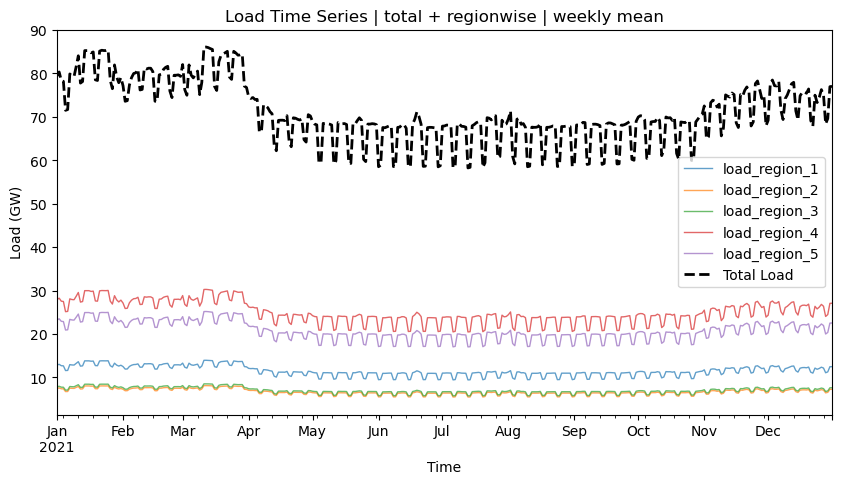

In [5]:
# PLOT - INPUT of interest: LOAD TIMESERIES | plot annual | total + per region
plot_load_timeseries(zero_co2_model, save_path="load_timeseries_annual.png", resample_freq="D")  # Daily mean


# Outputs of Interests

### TOTAL SYSTEM COST per Technology

In [6]:
def system_cost(n):
    tsc = pd.concat([n.statistics.capex(), n.statistics.opex()], axis=1)
    return tsc.sum(axis=1).droplevel(0).div(1e9).round(2)  # billion €/a

In [7]:
system_cost(unlimited_co2_model)

carrier
battery storage                 2.11
hydrogen storage underground    1.91
HVAC                            0.66
onwind                          3.13
solar                           8.11
biomass                         0.16
coal                            7.35
nuclear                         1.13
oil                             0.21
dtype: float64

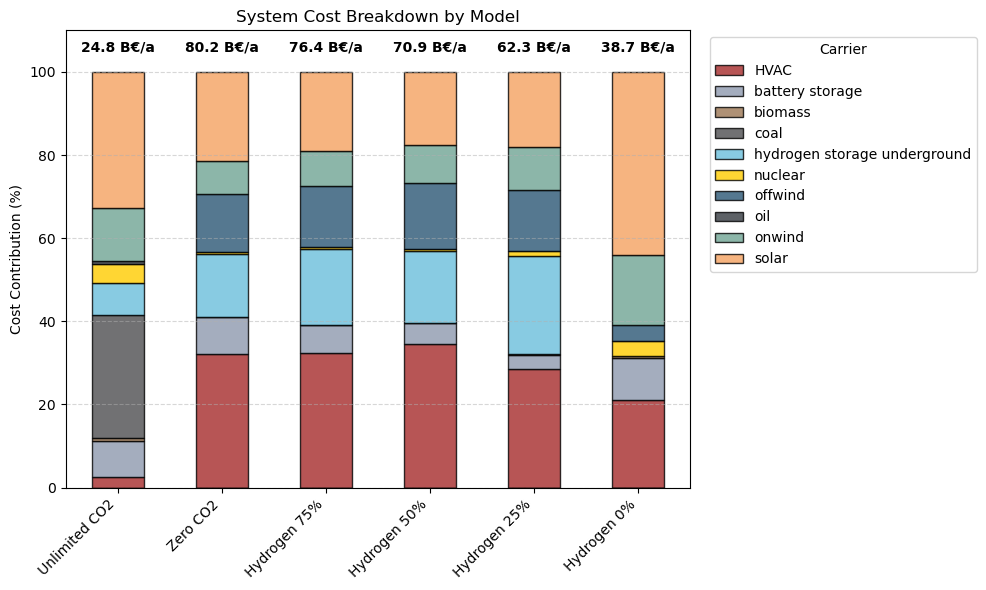

In [8]:
# CODE + PLOT - OUTPUT of interest: TOTAL SYSTEM COST | barplot per model | stacked shares of system cost

import matplotlib.pyplot as plt
import pandas as pd

# Models and their names
models = {
    "Unlimited CO2": unlimited_co2_model,
    "Zero CO2": zero_co2_model,
    "Hydrogen 75%": sensitivity_75,
    "Hydrogen 50%": sensitivity_50,
    "Hydrogen 25%": sensitivity_25,
    "Hydrogen 0%": sensitivity_00,
}

# Compute system costs
costs = {name: system_cost(n) for name, n in models.items()}
cost_df = pd.DataFrame(costs).fillna(0)  # Fill missing carriers with 0

# Compute % of total cost per model
total_costs = cost_df.sum()
cost_df_percent = cost_df.div(total_costs) * 100  # Convert to percentage

# Get consistent carrier colors from one model (all models share same carriers)
carrier_colors = {carrier: zero_co2_model.carriers.color.get(carrier, "gray") for carrier in cost_df.index}

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
cost_df_percent.T.plot(
    kind="bar", stacked=True, ax=ax, color=[carrier_colors[carrier] for carrier in cost_df.index], 
    edgecolor="black", alpha=0.8
)

# Annotate total system cost on top of each bar
for i, (model, total) in enumerate(total_costs.items()):
    ax.text(i, 105, f"{total:.1f} B€/a", ha="center", fontsize=10, fontweight="bold")

# Labels, title, and legend
ax.set_ylabel("Cost Contribution (%)")
ax.set_title("System Cost Breakdown by Model")
ax.set_xticklabels(cost_df_percent.columns, rotation=45, ha="right")
ax.legend(title="Carrier", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 110)  # Extra space for annotations

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# save_path
save_path = "system_cost_total_per_tech_all_models.png"
fig.savefig(save_path, bbox_inches='tight')


# Capacities built per Technology

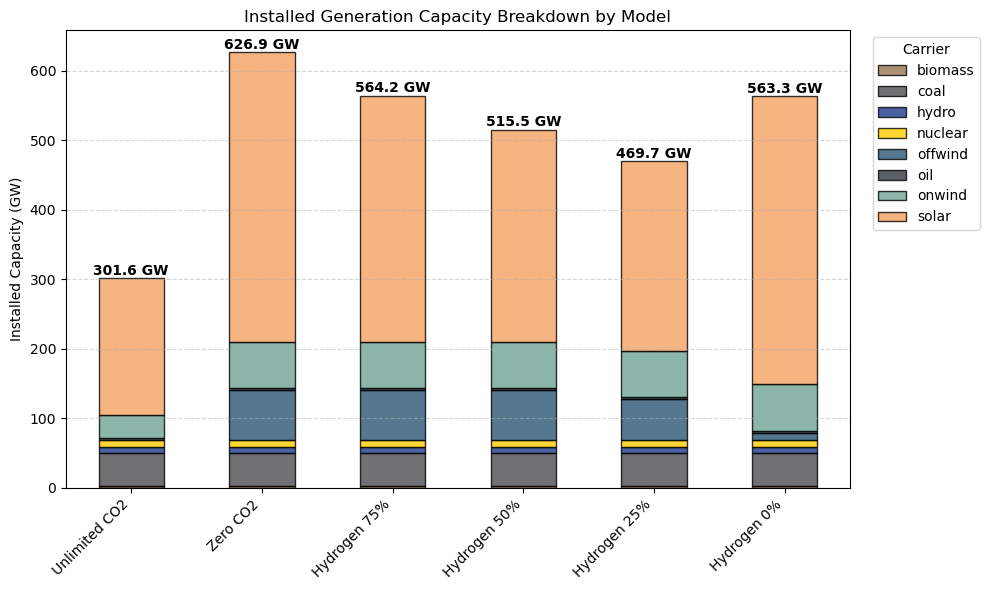

In [9]:

def total_capacity(n):
    return n.generators.p_nom_opt.groupby(n.generators.carrier).sum().div(1e3)  # Convert to GW

# Compute capacities for all models
capacities = {name: total_capacity(n) for name, n in models.items()}
capacity_df = pd.DataFrame(capacities).fillna(0)  # Fill missing carriers with 0

# Get consistent carrier colors from one model
carrier_colors = {carrier: zero_co2_model.carriers.color.get(carrier, "gray") for carrier in capacity_df.index}

# Plot stacked bar chart (Absolute values in GW)
fig, ax = plt.subplots(figsize=(10, 6))
capacity_df.T.plot(
    kind="bar", stacked=True, ax=ax, 
    color=[carrier_colors[carrier] for carrier in capacity_df.index], 
    edgecolor="black", alpha=0.8
)

# Annotate total installed capacity on top of each bar
for i, (model, total) in enumerate(capacity_df.sum().items()):
    ax.text(i, total + 5, f"{total:.1f} GW", ha="center", fontsize=10, fontweight="bold")

# Labels, title, and legend
ax.set_ylabel("Installed Capacity (GW)")
ax.set_title("Installed Generation Capacity Breakdown by Model")
ax.set_xticklabels(capacity_df.columns, rotation=45, ha="right")
ax.legend(title="Carrier", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [10]:
def total_capacity_storage(n):
    return n.storage_units.p_nom_opt.groupby(n.storage_units.carrier).sum().div(1e3)

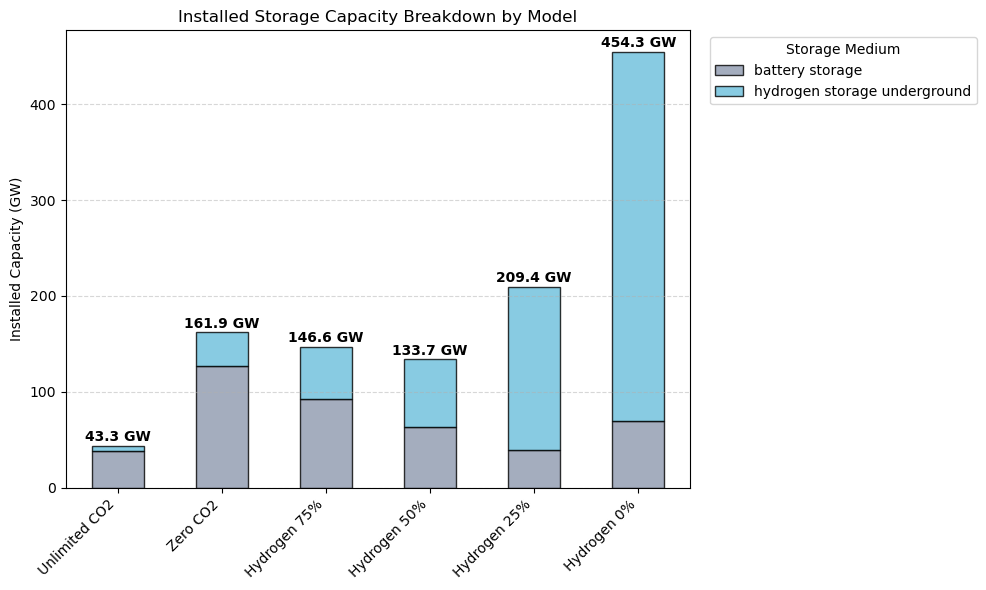

In [11]:

# Compute capacities for all models
capacities = {name: total_capacity_storage(n) for name, n in models.items()}
capacity_df = pd.DataFrame(capacities).fillna(0)  # Fill missing carriers with 0

# Get consistent carrier colors from one model
carrier_colors = {carrier: zero_co2_model.carriers.color.get(carrier, "gray") for carrier in capacity_df.index}

# Plot stacked bar chart (Absolute values in GW)
fig, ax = plt.subplots(figsize=(10, 6))
capacity_df.T.plot(
    kind="bar", stacked=True, ax=ax, 
    color=[carrier_colors[carrier] for carrier in capacity_df.index], 
    edgecolor="black", alpha=0.8
)

# Annotate total installed capacity on top of each bar
for i, (model, total) in enumerate(capacity_df.sum().items()):
    ax.text(i, total + 5, f"{total:.1f} GW", ha="center", fontsize=10, fontweight="bold")

# Labels, title, and legend
ax.set_ylabel("Installed Capacity (GW)")
ax.set_title("Installed Storage Capacity Breakdown by Model")
ax.set_xticklabels(capacity_df.columns, rotation=45, ha="right")
ax.legend(title="Storage Medium", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [12]:
from collections import OrderedDict

In [13]:

def plot_dispatch(n, time="2021", title="Test", save_path=None, frequency = "D", x=50, y=120):
    # Group by carrier and sum, dividing by 1000
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T.div(1e3)

    # Include storage units if available
    if not n.storage_units.empty:
        sto = n.storage_units_t.p.T.groupby(n.storage_units.carrier).sum().T.div(1e3)
        p_by_carrier = pd.concat([p_by_carrier, sto], axis=1)

    # Resample to weekly means
    p_by_carrier = p_by_carrier.resample(frequency).mean()

    fig, ax = plt.subplots(figsize=(16, 10))

    color = p_by_carrier.columns.map(n.carriers.color)

    # Plot positive values (generation)
    p_by_carrier_pos = p_by_carrier.where(p_by_carrier > 0)
    if not p_by_carrier_pos.empty:
        p_by_carrier_pos.loc[time].plot.area(ax=ax, linewidth=0, color=color)

    # Plot negative values (charge)
    charge = p_by_carrier.where(p_by_carrier < 0).dropna(how="all", axis=1)
    if not charge.empty:
        charge.loc[time].plot.area(ax=ax, linewidth=0, color=charge.columns.map(n.carriers.color))

    # Resample load (demand) to weekly means
    load_data = n.loads_t.p_set.sum(axis=1).div(1e3).resample(frequency).mean()

    # Plot load
    load_data.loc[time].plot(ax=ax, c='k', label='Demand')

    # Combine all labels and handles
    handles, labels = ax.get_legend_handles_labels()

    # Replace 'hydrogen storage underground' with 'hydrogen storage'
    labels = ['hydrogen storage' if label == 'hydrogen storage underground' else label for label in labels]

    # Remove duplicates while maintaining order
    by_label = OrderedDict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc=(1.05, 0),fontsize=14, title="Carrier", title_fontsize=14 )

    ax.set_title(title, fontsize =16)
    ax.set_ylabel("GW", fontsize =16)
    ax.tick_params(axis="both", labelsize=16)

    # Adjust y-limits to avoid singular transformation issue
    ymin, ymax = ax.get_ylim()
    if ymin == ymax:
        ax.set_ylim(ymin - 1, ymax + 1)
    else:
        ax.set_ylim(-x, y)

    # Save the figure if save_path is provided
    if save_path:
        fig.savefig(save_path, bbox_inches='tight')

    plt.show()


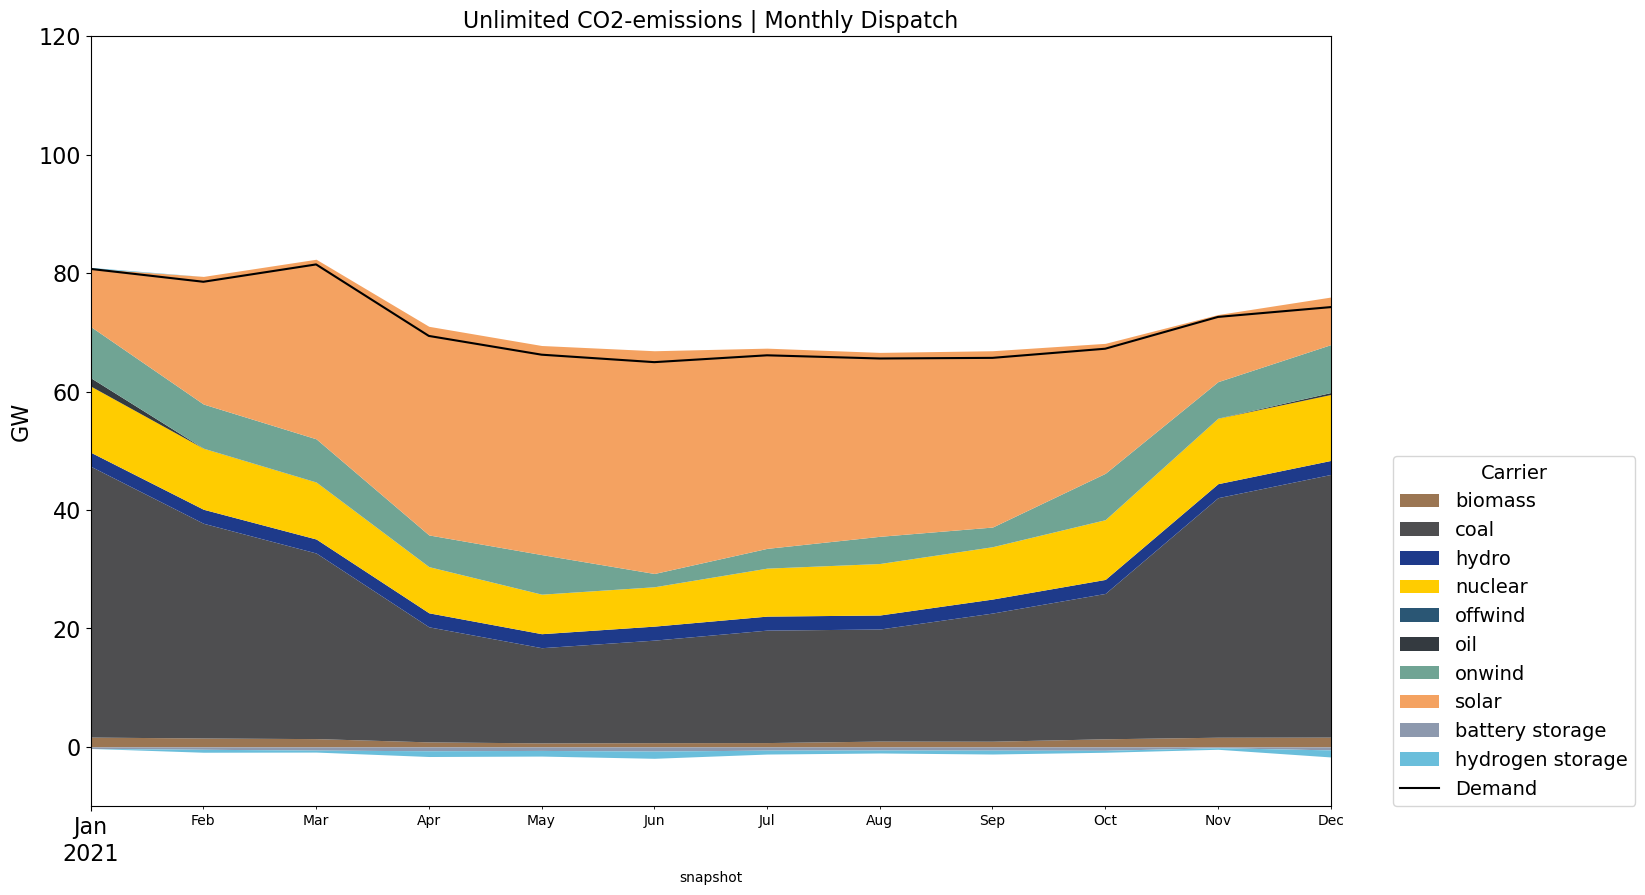

In [15]:
plot_dispatch(unlimited_co2_model, "2021", title="Unlimited CO2-emissions | Monthly Dispatch", frequency="ME", x=10)

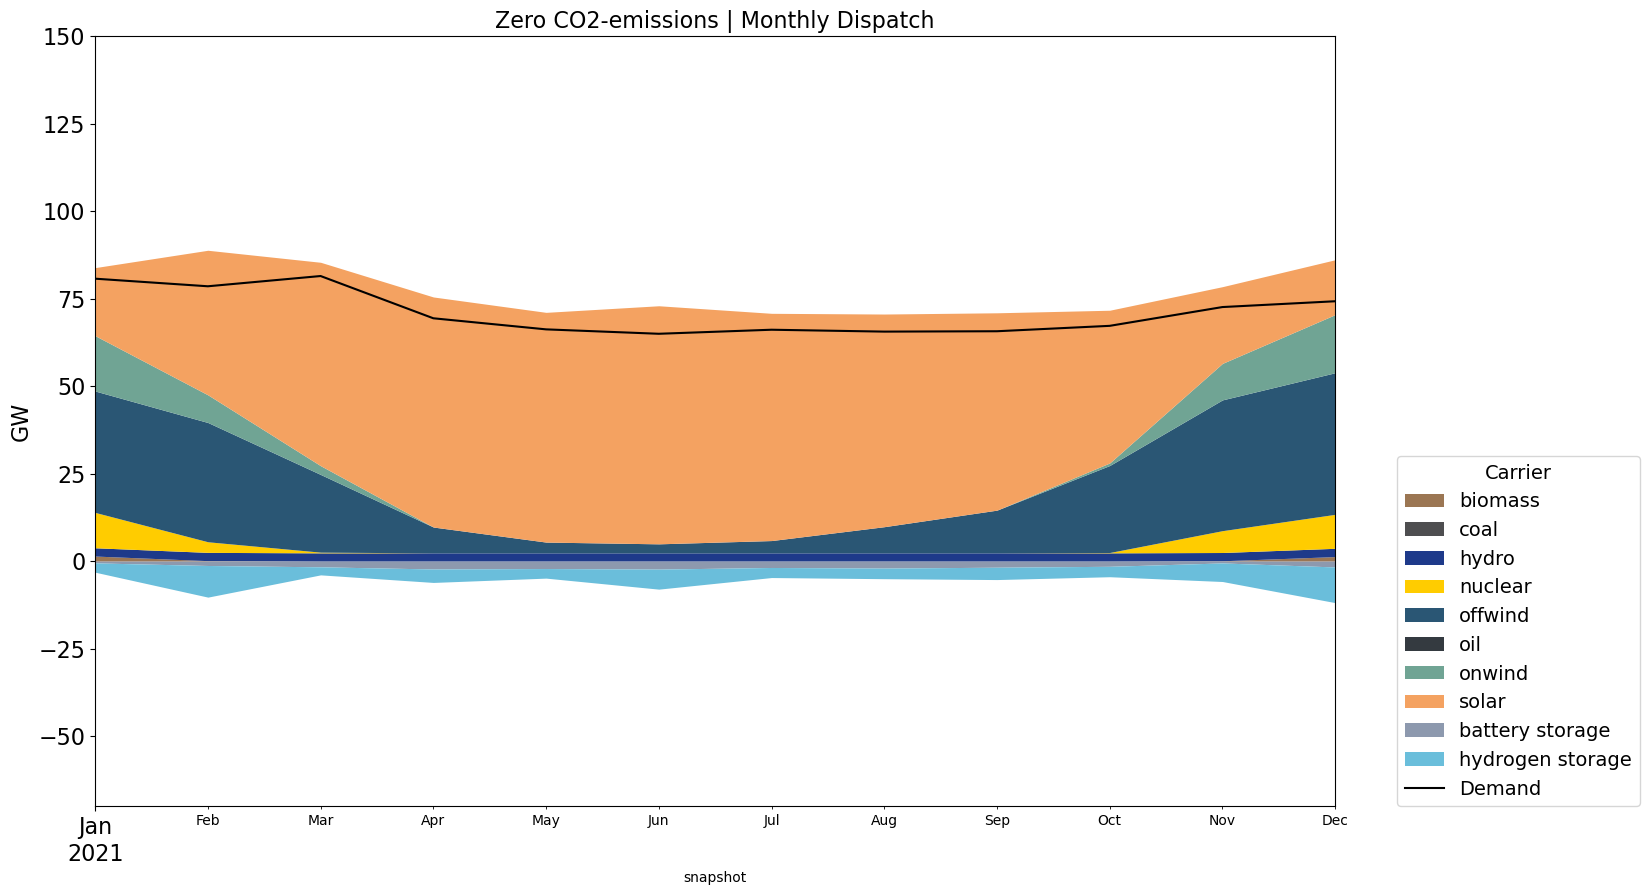

In [16]:
plot_dispatch(zero_co2_model, "2021", title="Zero CO2-emissions | Monthly Dispatch", frequency="ME", x=70, y=150)

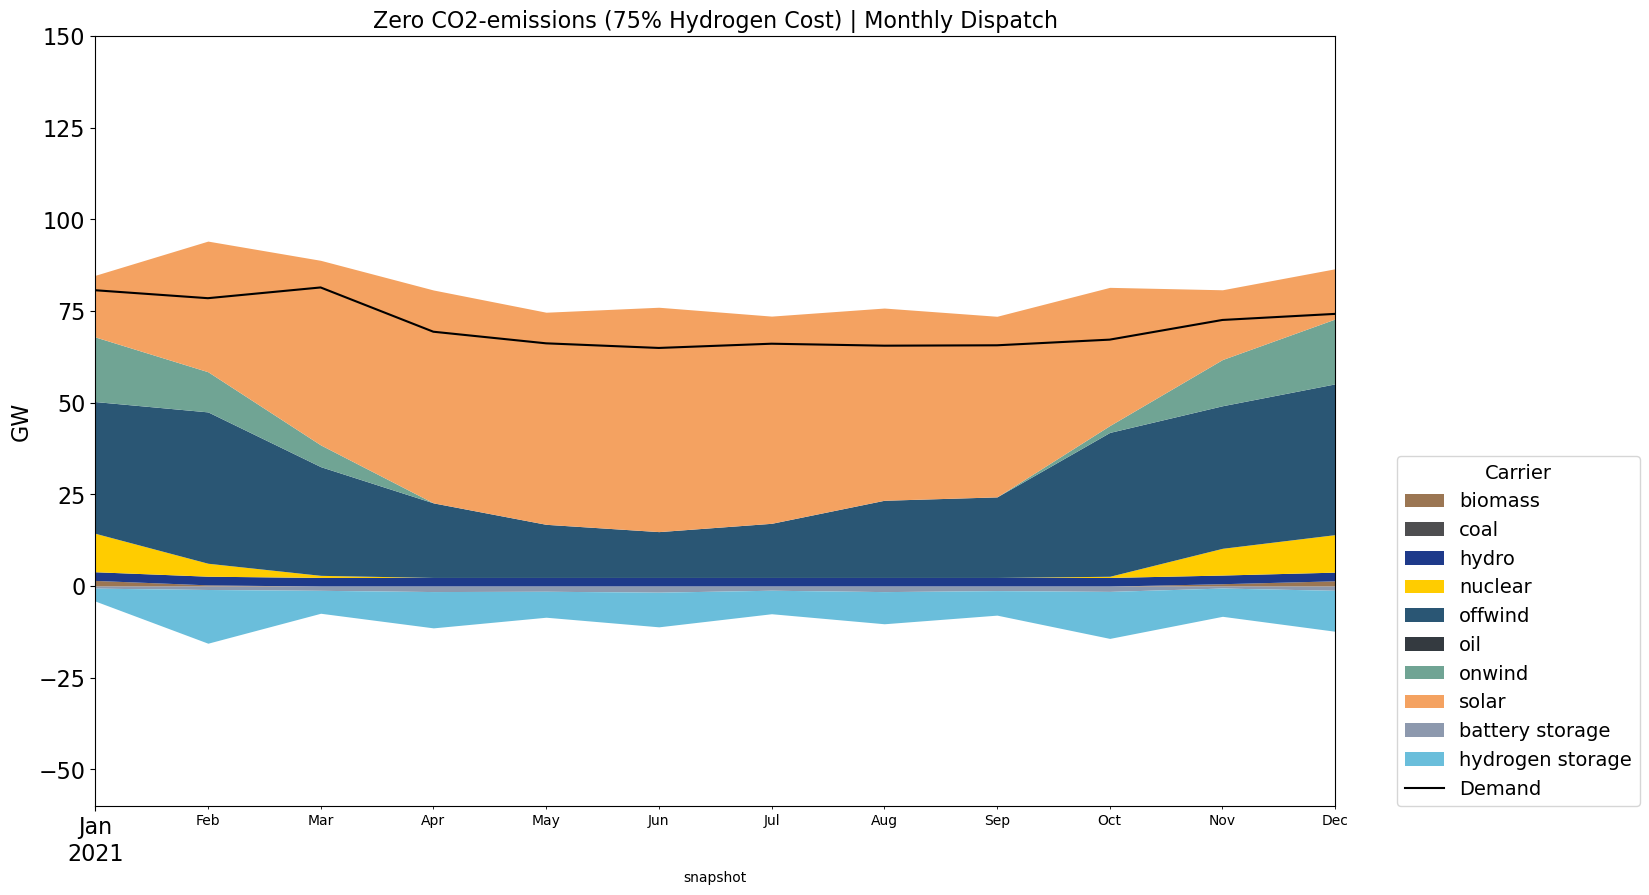

In [21]:
plot_dispatch(sensitivity_75, "2021", title="Zero CO2-emissions (75% Hydrogen Cost) | Monthly Dispatch", frequency="ME", x=60, y=150)

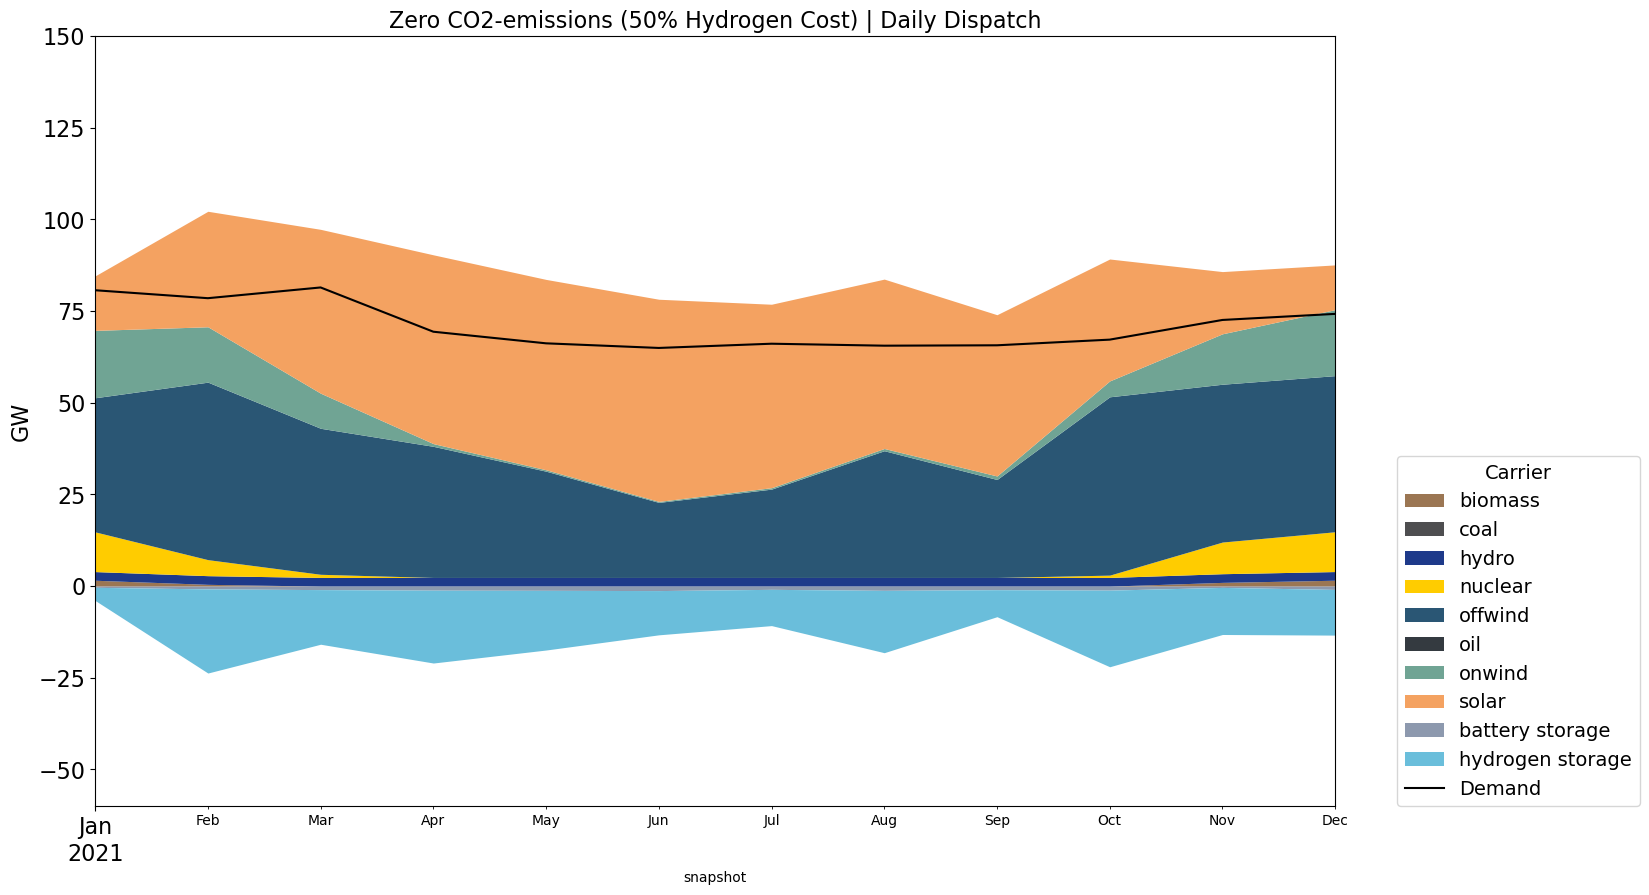

In [18]:
plot_dispatch(sensitivity_50, "2021", title="Zero CO2-emissions (50% Hydrogen Cost) | Daily Dispatch", frequency="ME", x=60, y=150)

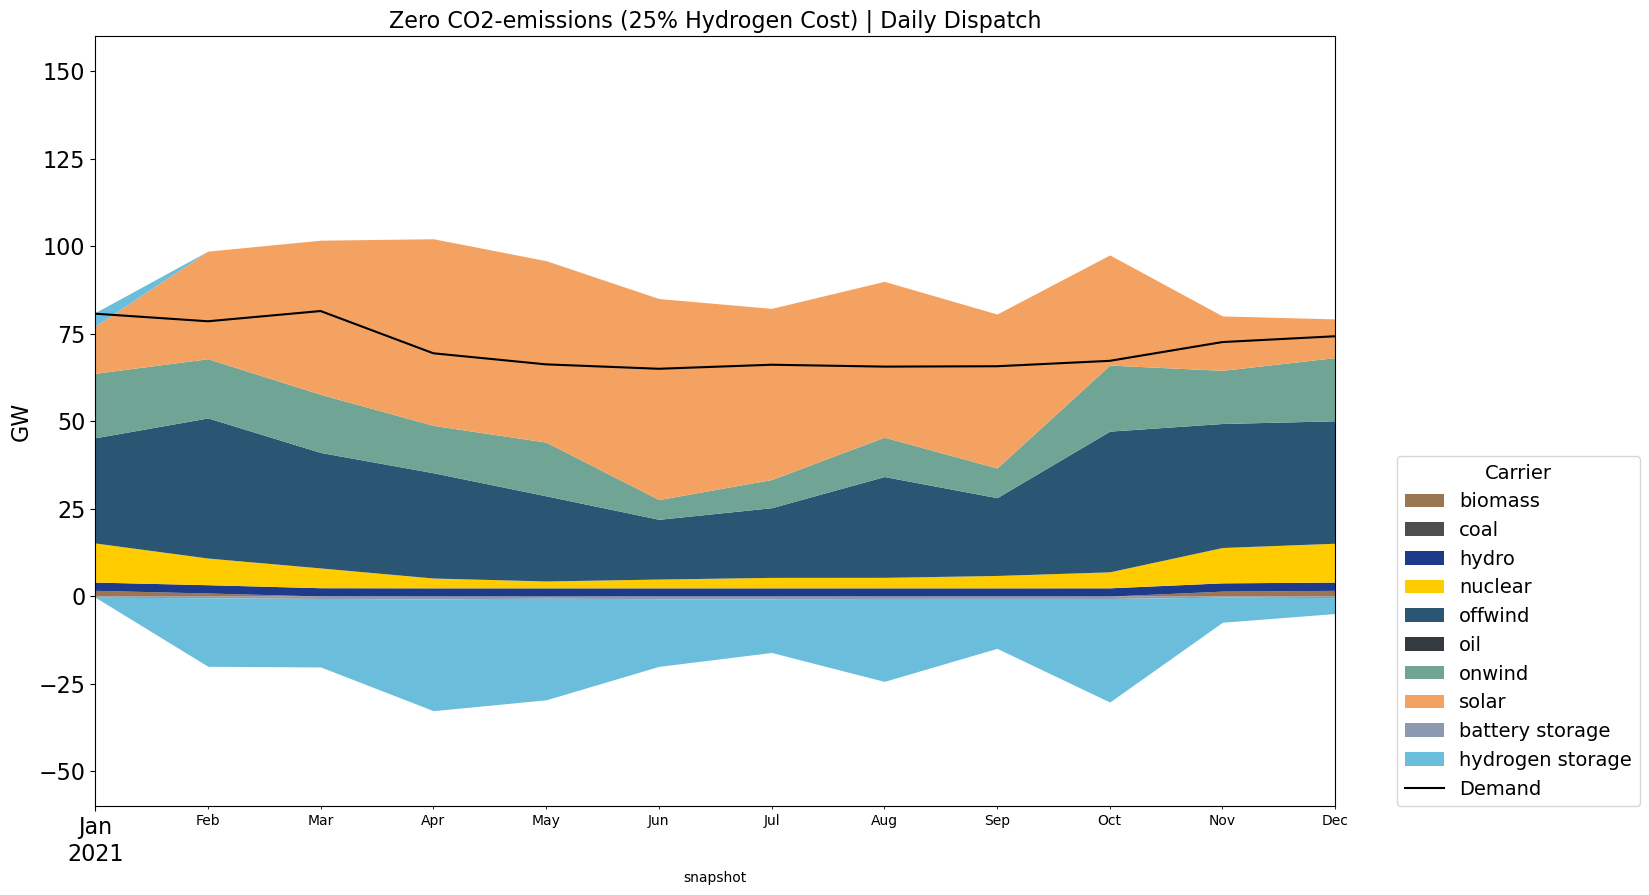

In [19]:
plot_dispatch(sensitivity_25, "2021", title="Zero CO2-emissions (25% Hydrogen Cost) | Daily Dispatch", frequency="ME", x= 60, y=160)

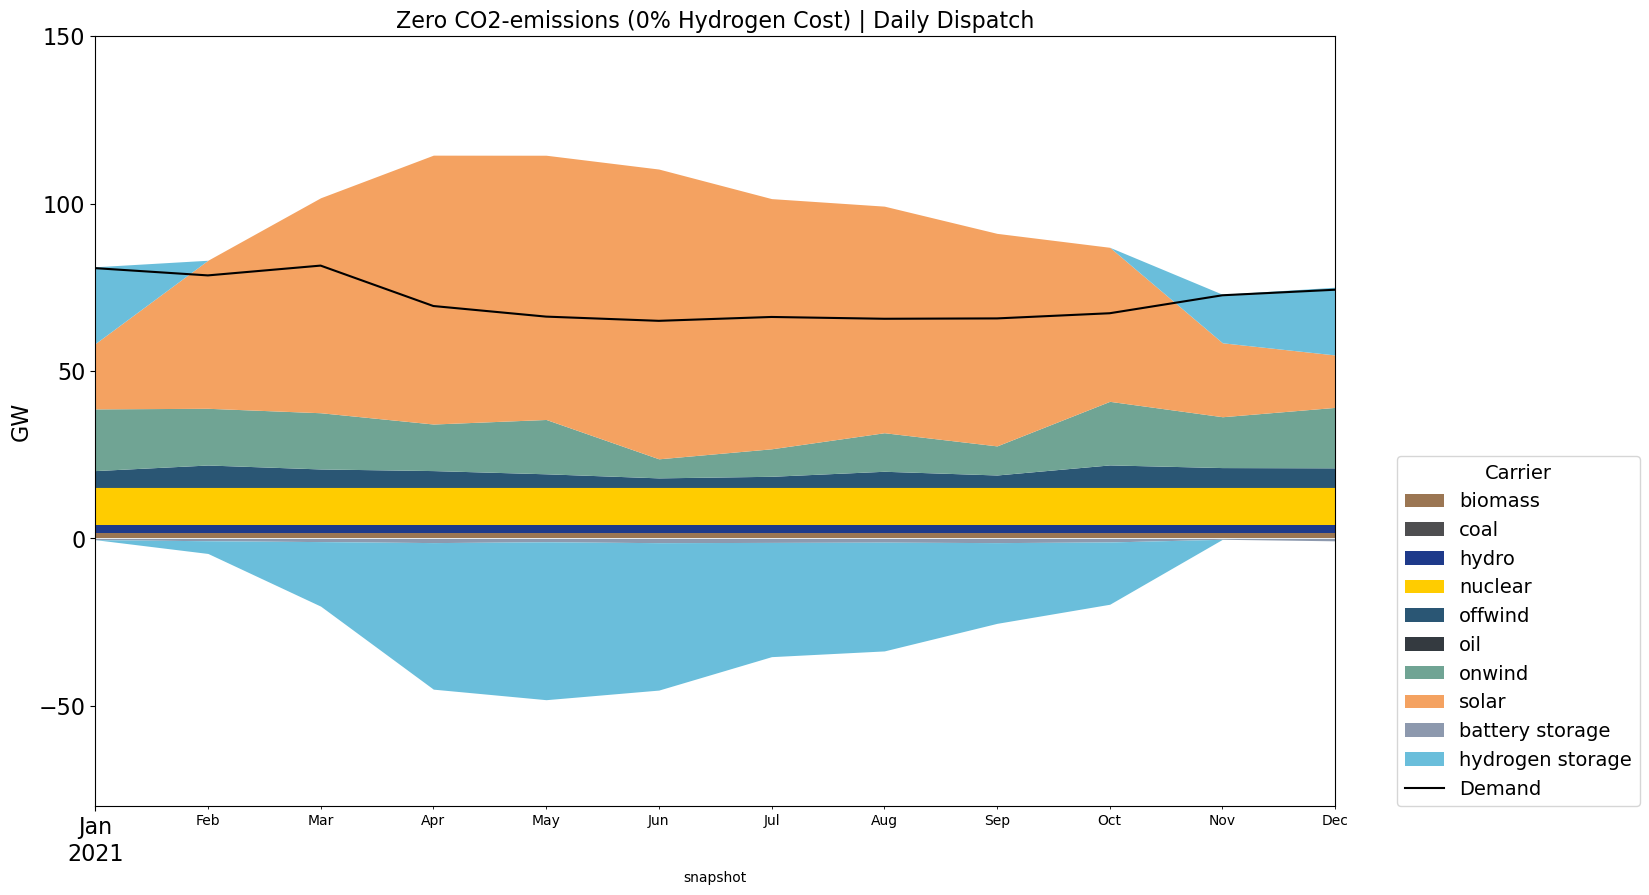

In [20]:
plot_dispatch(sensitivity_00, "2021", title="Zero CO2-emissions (0% Hydrogen Cost) | Daily Dispatch", frequency="ME", x= 80, y=150)

# Price Duration Curves

In [19]:
def get_price_duration_curve(n):
    avg_prices = n.buses_t.marginal_price.mean(axis=1)  # Average system price
    avg_prices = avg_prices.replace(0, np.nan).fillna(0.01)  # Replace 0s for log scale
    return avg_prices.sort_values(ascending=False).reset_index(drop=True)

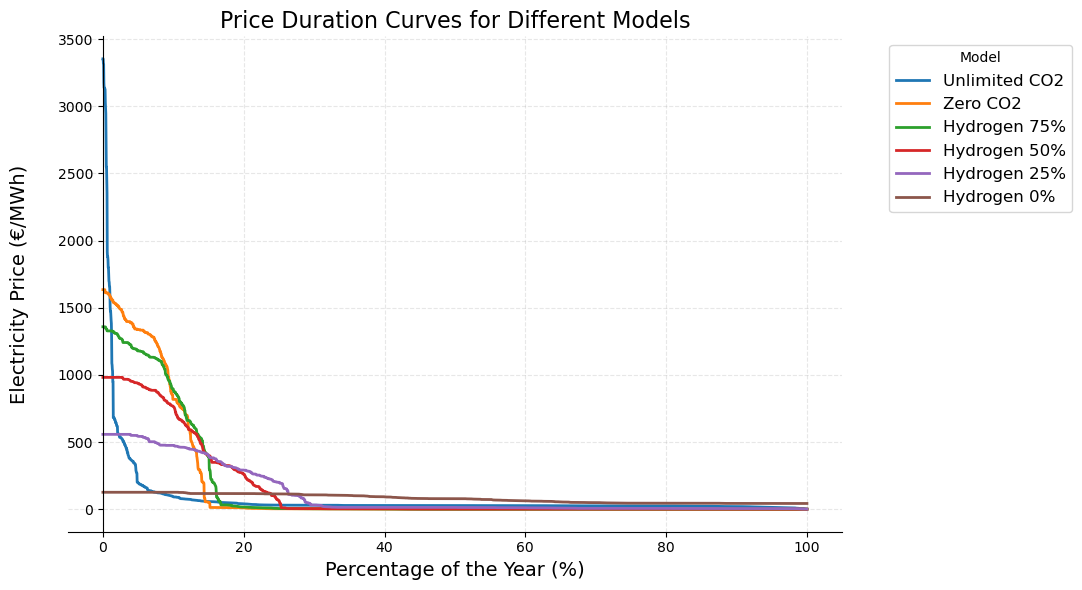

In [20]:
# Compute price duration curves for all models
price_curves = {name: get_price_duration_curve(n) for name, n in models.items()}

# Get the number of time steps (assuming all models have the same length)
time_steps = len(next(iter(price_curves.values())))
x_values = np.linspace(0, 100, time_steps)  # Convert to percentage of the year

# Prepare to plot price duration curves
fig, ax = plt.subplots(figsize=(14-3, 6))

# Store line and average price objects for legend sorting
lines = []
average_lines = []

# Compute and plot the price duration curves and average price lines
for name, curve in price_curves.items():
    # Plot the duration curve with a color
    line, = ax.plot(x_values, curve, label=name, linewidth=2)
    lines.append((line, name))
    
    # Compute the average price for each model
    avg_price = curve.mean()

# Move y-axis to x = 0
ax.spines["left"].set_position(("data", 0))  
ax.spines["right"].set_visible(False)  
ax.spines["top"].set_visible(False)  
ax.yaxis.set_label_coords(-0.05, 0.5)  # Adjust y-axis label position

# Labels, title
ax.set_xlabel("Percentage of the Year (%)", fontsize=14)
ax.set_ylabel("Electricity Price (€/MWh)", fontsize=14)  # Removed log scale reference
ax.set_title("Price Duration Curves for Different Models", fontsize=16)

# Combine the duration curves and average lines for sorted legend
sorted_lines = sorted(lines, key=lambda x: x[0].get_ydata()[0], reverse=True)  # Sort by starting y-value of the curve
sorted_average_lines = sorted(average_lines, key=lambda x: float(x[1].split('(')[1].split('€/')[0]), reverse=True)  # Sort by avg price

# Create a sorted legend
sorted_legend_labels = [line[1] for line in sorted_lines] + [line[1] for line in sorted_average_lines]
sorted_legend_handles = [line[0] for line in sorted_lines] + [line[0] for line in sorted_average_lines]

# Place legend outside to the right of the plot
ax.legend(sorted_legend_handles, sorted_legend_labels, title="Model", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=12)

# Grid
ax.grid(True, linestyle="--", alpha=0.3, which="both")  # Both major & minor grid

# Adjust layout to make room for the legend
plt.tight_layout()

# Show plot
plt.show()

# Save figure
save_path = "price_duration_curves_all_models_inkl_avg_prices.png"
fig.savefig(save_path, bbox_inches='tight')


## Avergae Price per Region

In [21]:
def get_region_avg_price(n):
    # Extract the marginal price data for each region (assuming it is in a DataFrame like the example you provided)
    avg_prices = n.buses_t.marginal_price.mean(axis=0)  # Average over time for each region
    return avg_prices

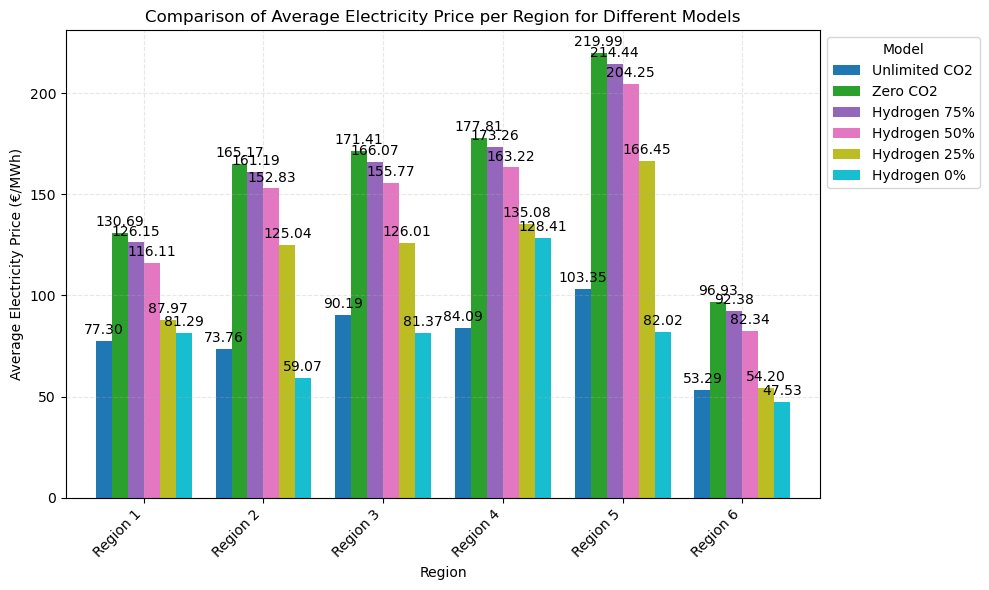

In [22]:

# Compute average prices for each model
region_avg_prices = {name: get_region_avg_price(n) for name, n in models.items()}

# Combine the average prices for each model into a DataFrame
avg_prices_df = pd.DataFrame(region_avg_prices)

# Plotting for all models in one figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot grouped bar chart
avg_prices_df.plot(kind="bar", ax=ax, color=plt.cm.get_cmap('tab10', len(models)).colors, width=0.8)

# Labels, title
ax.set_xlabel("Region")
ax.set_ylabel("Average Electricity Price (€/MWh)")
ax.set_title("Comparison of Average Electricity Price per Region for Different Models")
ax.set_xticklabels(avg_prices_df.index, rotation=45, ha='right')

# Display the average prices on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                xytext=(0, 5), textcoords="offset points", ha='center', fontsize=10)

# Legend and grid
ax.legend(title="Model", loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(True, linestyle="--", alpha=0.3)

# Tight layout and show the plot
plt.tight_layout()
plt.show()

# Save the figure
save_path = "avg_price_comparison_all_models_per_region.png"
fig.savefig(save_path, bbox_inches='tight')


## Storage Filling Levels

In [23]:
def plot_storage_filling(n, title=None, save_path=None):
    # Accessing the state of charge data
    state_of_charge = n.storage_units_t.state_of_charge.sum(axis=1).div(1e3)  # Convert to GWh

    # Use datetime index for the x-axis
    x_values = state_of_charge.index  # Datetime index

    # Plotting the state of charge over the whole year
    fig, ax = plt.subplots(figsize=(18, 9))

    # Plot state of charge
    ax.plot(x_values, state_of_charge, color='blue', linewidth=1)

    # Add a horizontal line for the max storage level
    max_storage = state_of_charge.max()  # Max value of state of charge
    ax.axhline(max_storage, color='red', linestyle='--', linewidth=1, label=f"Max Storage Level: {max_storage:.2f} GWh")

    # Labels, title
    ax.set_xlabel("Time", fontsize = 20)
    ax.set_ylabel("State of Charge (GWh)", fontsize = 20)
    ax.set_title(title, fontsize = 20)

    # Ensure the x-axis shows readable dates
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))  # Limit number of x-axis labels

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, fontsize=14)
    plt.yticks(fontsize=14)
    # Add a grid
    ax.grid(True, linestyle="--", alpha=0.3)

    # Add legend
    ax.legend(loc='lower right', fontsize=20)

    # Display the plot
    plt.tight_layout()
    plt.show()

    # Save the plot if a path is provided
    if save_path:
        fig.savefig(save_path, bbox_inches='tight')



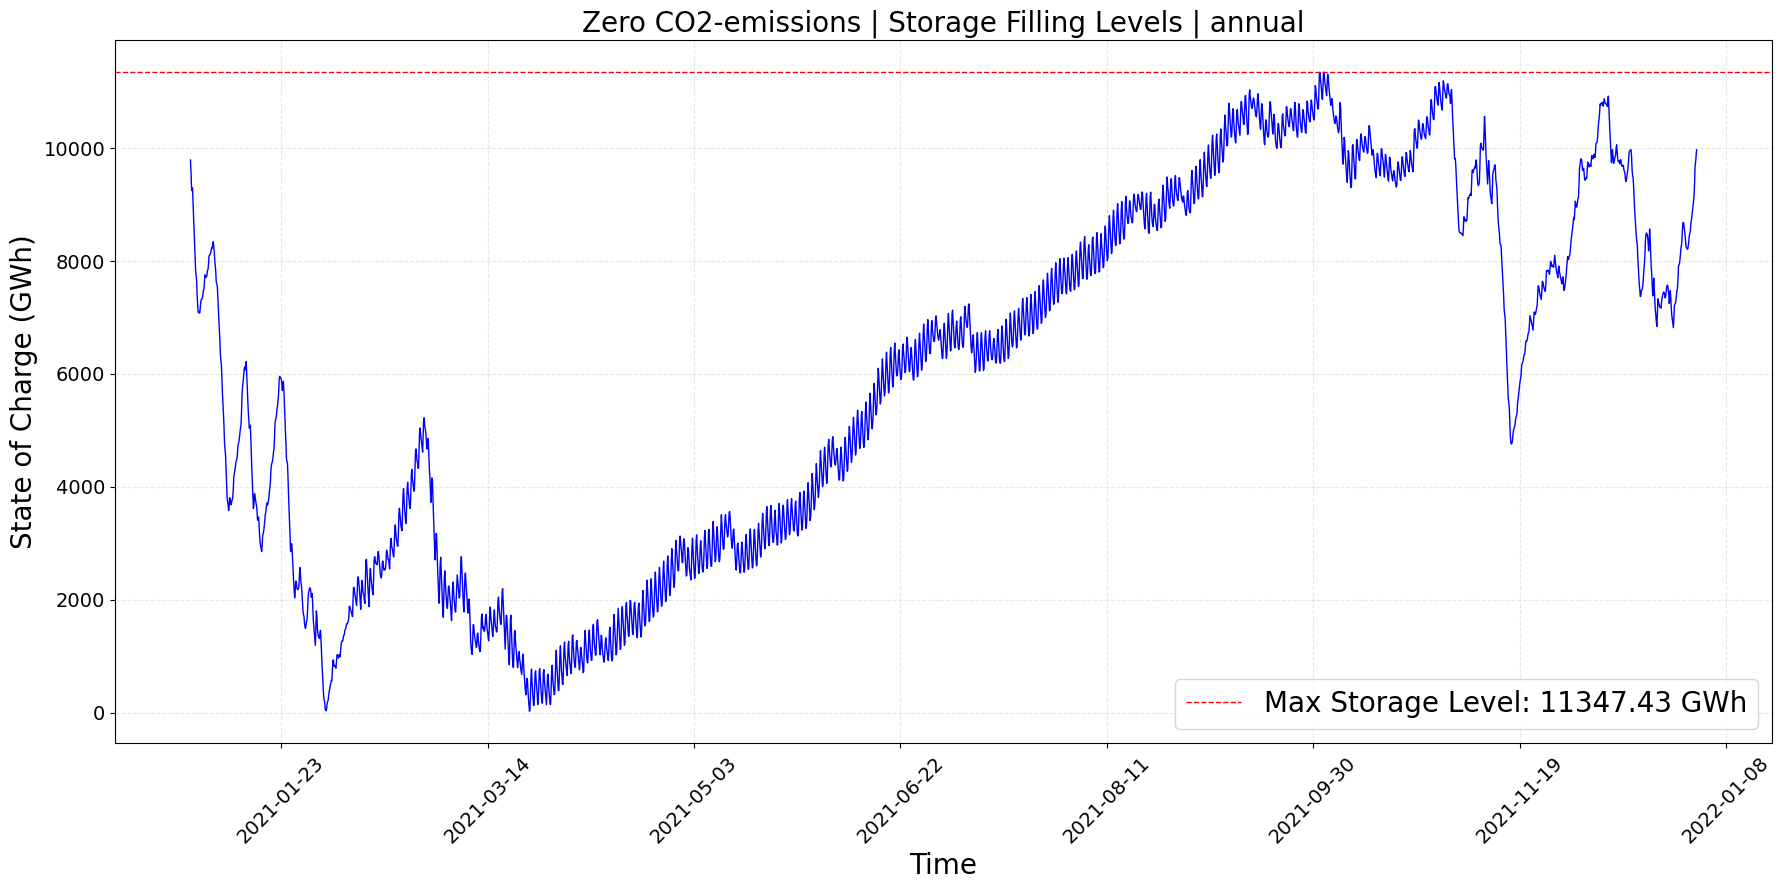

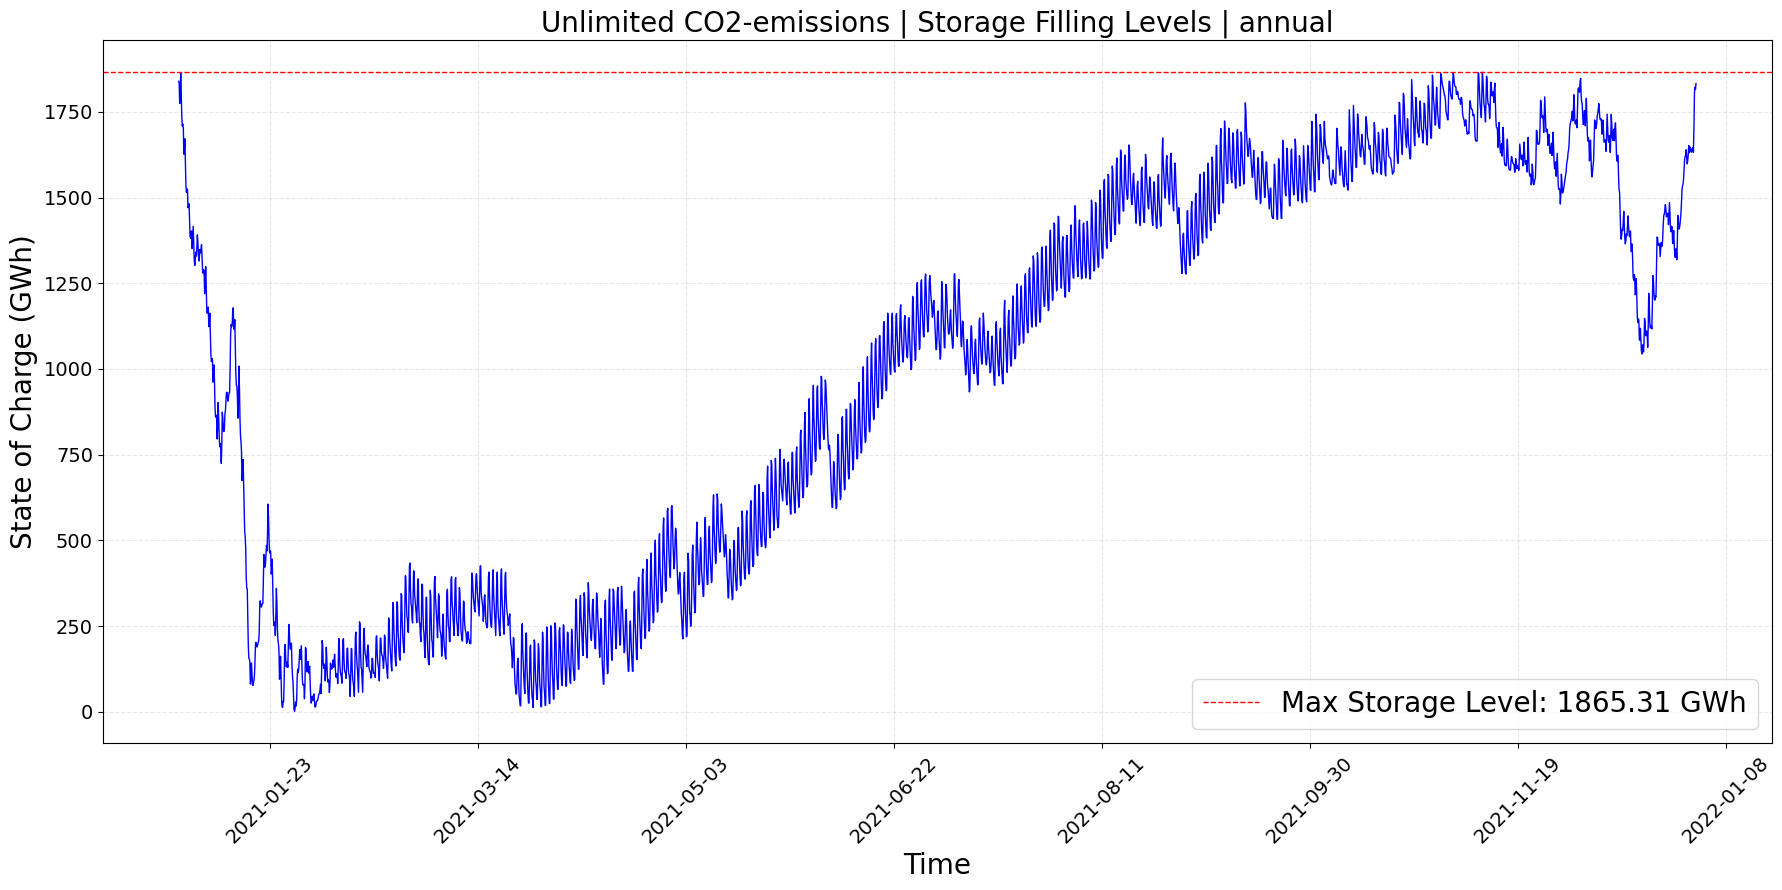

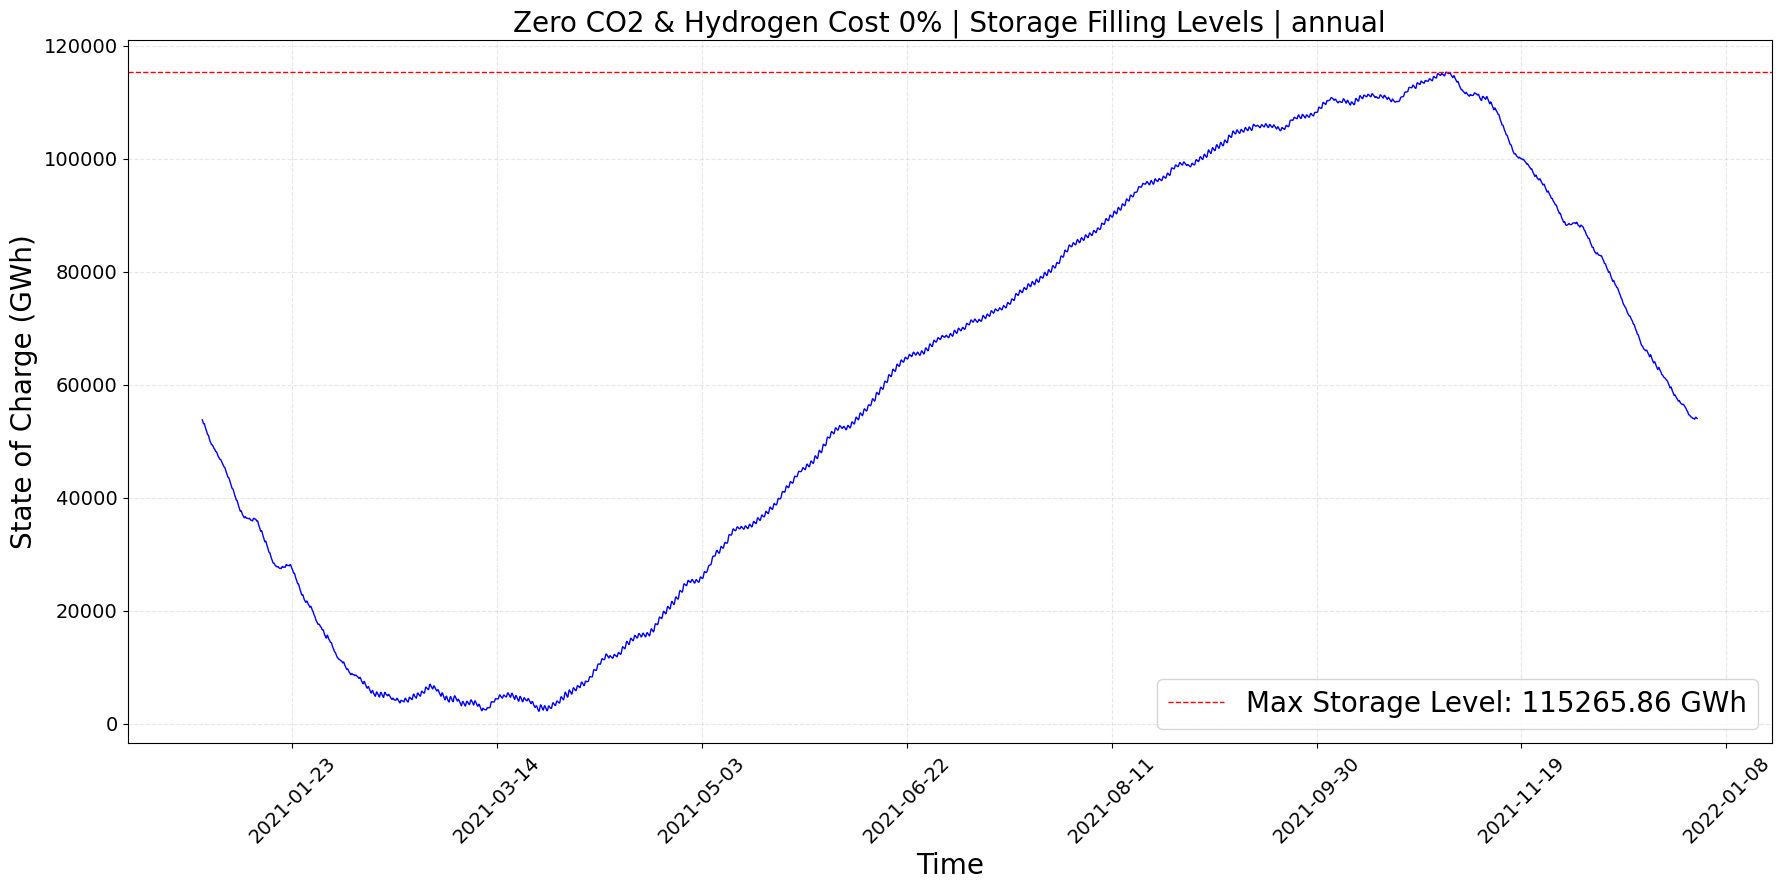

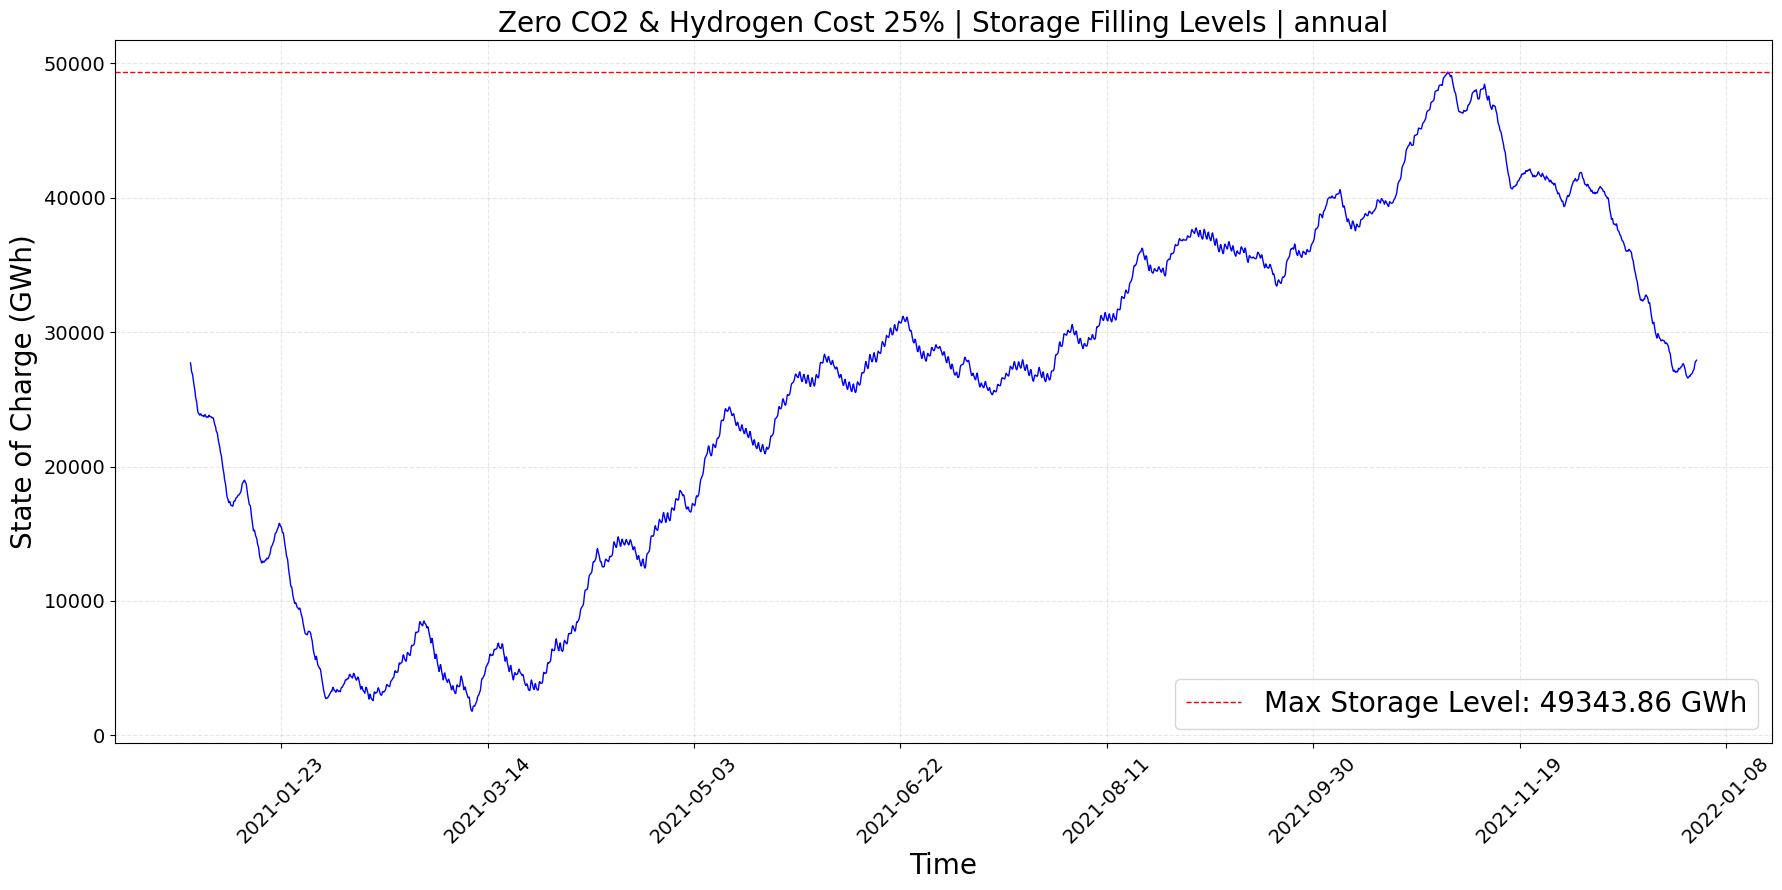

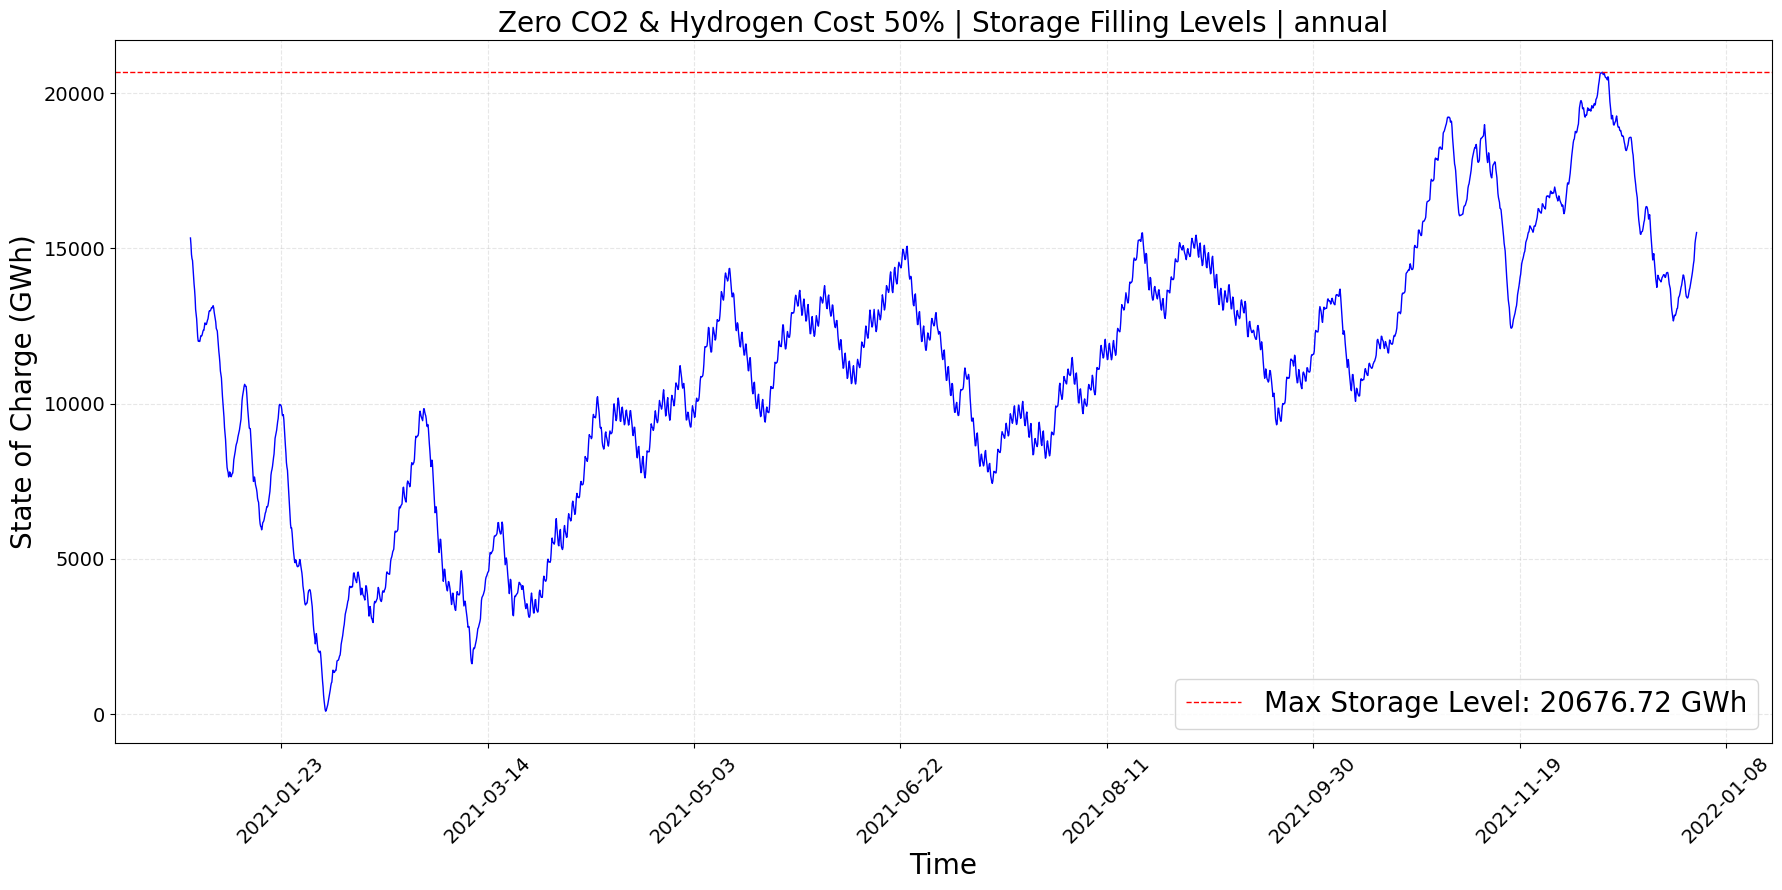

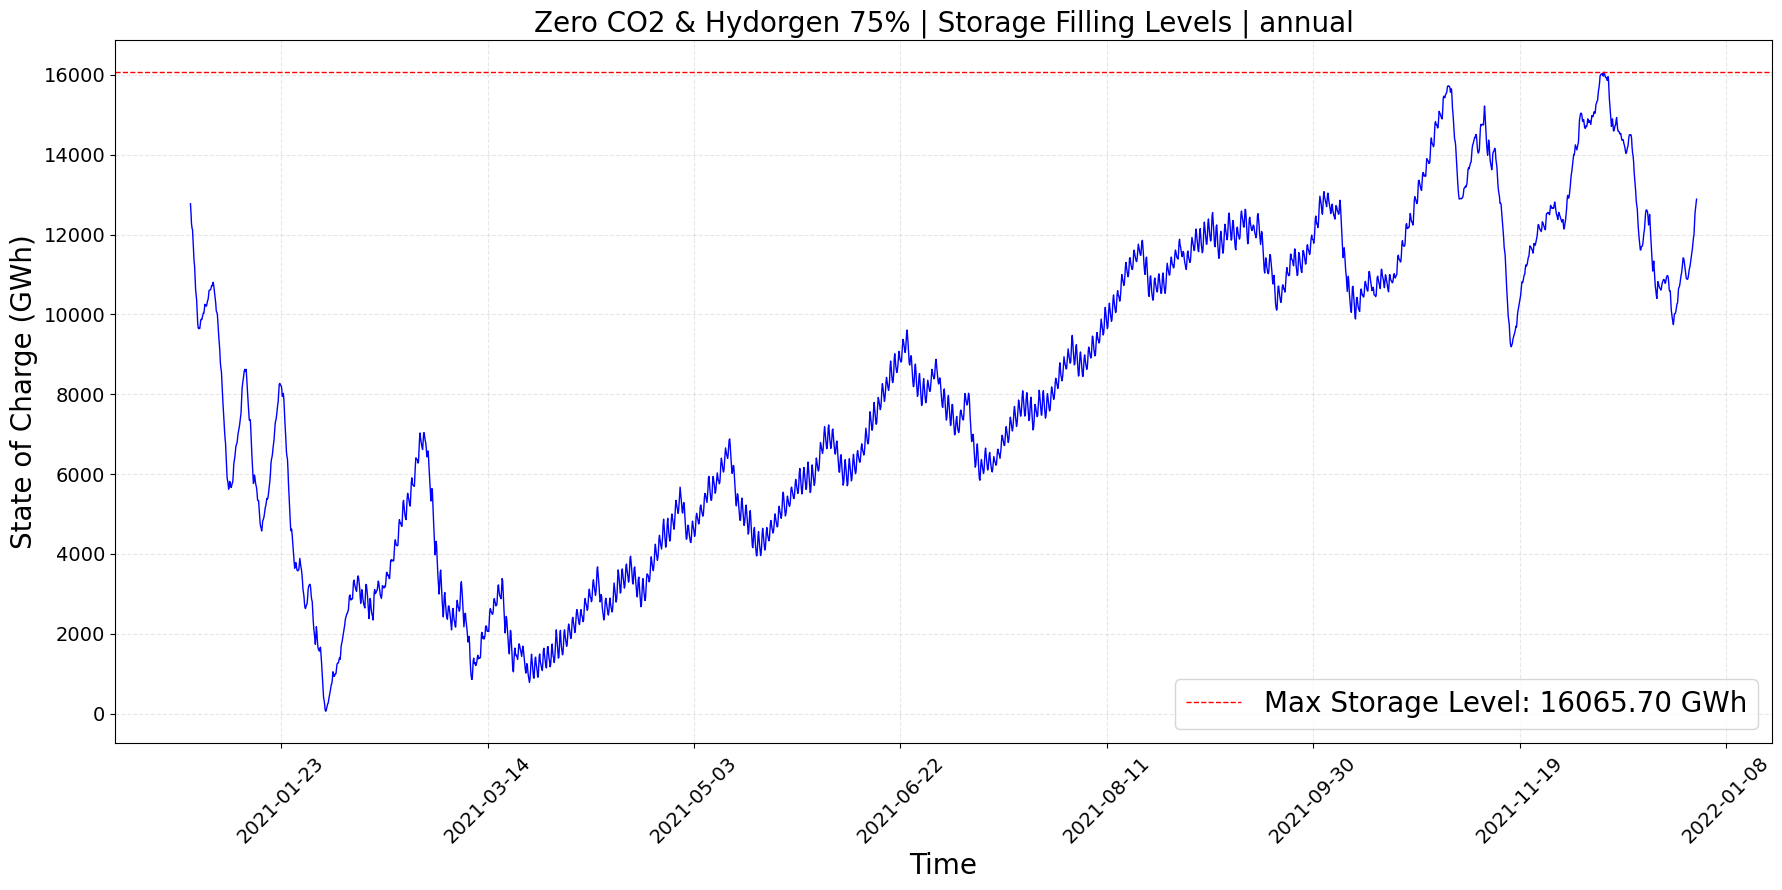

In [24]:
# PLOT - OUTPUT of interest: ELECTRICITY-MIX | plot annual | total + per region

plot_storage_filling(zero_co2_model, "Zero CO2-emissions | Storage Filling Levels | annual", "zero_CO2_storage_level_annual.png")
plot_storage_filling(unlimited_co2_model, "Unlimited CO2-emissions | Storage Filling Levels | annual", "unlimited_CO2_storage_level_annual.png")
plot_storage_filling(sensitivity_00, "Zero CO2 & Hydrogen Cost 0% | Storage Filling Levels | annual", "zero_co2_SENS_electrolysis_00_storage_level_annual.png")
plot_storage_filling(sensitivity_25, "Zero CO2 & Hydrogen Cost 25% | Storage Filling Levels | annual", "zero_co2_SENS_electrolysis_25_storage_level_annual.png")
plot_storage_filling(sensitivity_50, "Zero CO2 & Hydrogen Cost 50% | Storage Filling Levels | annual", "zero_co2_SENS_electrolysis_50_storage_level_annual.png")
plot_storage_filling(sensitivity_75, "Zero CO2 & Hydorgen 75% | Storage Filling Levels | annual", "zero_co2_SENS_electrolysis_75_storage_level_annual.png")
